In [1]:
import pandas as pd
import numpy as np

In [2]:
%pwd
%cd /home/jovyan/work/results/Cell/
%pwd

/home/jovyan/work/results/Cell


'/home/jovyan/work/results/Cell'

In [3]:
# import the PCC data
pcc_4S = pd.read_csv("pcc_4S.csv", index_col=0)
pcc_I = pd.read_csv("pcc_I.csv", index_col=0)
pcc_III = pd.read_csv("pcc_III.csv", index_col=0)
pcc_IV = pd.read_csv("pcc_IV.csv", index_col=0)
# pcc_NA = pd.read_csv("pcc_NA.csv", index_col=0)
pcc_4S

,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,1.000000,0.101876,-0.105444,0.294110,0.285490,0.043094,0.273760,0.154205,0.535308,0.574785,...,-0.214314,-0.225862,0.491546,0.099288,0.247549,-0.177206,0.227948,-0.268659,0.047149,-0.721479
DPM1,0.101876,1.000000,0.040753,0.366840,0.112091,-0.203120,0.277659,0.230100,0.012097,-0.223822,...,-0.017635,-0.288416,0.410572,0.095112,0.348526,0.411757,-0.319794,-0.130364,0.225836,-0.290486
SCYL3,-0.105444,0.040753,1.000000,0.378629,-0.077102,0.299282,0.164965,0.239981,-0.208912,0.051952,...,0.622151,0.586767,0.021289,0.030100,0.392734,0.130584,0.244455,0.441587,0.019297,0.122590
C1orf112,0.294110,0.366840,0.378629,1.000000,0.090887,0.202204,0.276277,0.408218,-0.028448,0.043607,...,0.243748,0.095764,0.304032,0.119730,0.447024,-0.121551,0.210028,0.290213,-0.177887,-0.509990
FGR,0.285490,0.112091,-0.077102,0.090887,1.000000,-0.117195,0.082018,-0.002028,0.309746,0.378912,...,0.061240,0.080967,0.612712,0.711971,0.284195,0.071398,0.207367,-0.222435,0.442745,-0.239477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,-0.177206,0.411757,0.130584,-0.121551,0.071398,-0.431935,-0.214156,-0.163260,0.100622,-0.076020,...,0.350383,0.075384,0.190224,0.019012,0.208961,1.000000,-0.613841,-0.308633,0.599359,0.277204
CYB561D2,0.227948,-0.319794,0.244455,0.210028,0.207367,0.558621,0.306613,0.189181,0.124066,0.351359,...,0.070697,0.309529,0.159834,0.172155,0.138332,-0.613841,1.000000,0.342137,-0.458748,-0.186283
CCDC7,-0.268659,-0.130364,0.441587,0.290213,-0.222435,0.542627,0.210271,0.254534,-0.347429,-0.078083,...,0.285602,0.507611,-0.117943,-0.003734,0.117266,-0.308633,0.342137,1.000000,-0.371967,0.101145


In [4]:
# Set the name of the DataFrame
pcc_4S.name = "pcc_4S"
pcc_I.name = "pcc_I"
pcc_III.name = "pcc_III"
pcc_IV.name = "pcc_IV"
# pcc_NA.name = "pcc_NA"

construct a weighted graph of edges based on 1-abs(PCC-value)

delete rows and columns with Inf entries, since those genes are deleted from the module. (already ensured the genes won't contribute to potential modules candidates by assuring only 1 connected component is >= 3 in the previous graph)

In [5]:
import sys
sys.path.append('/home/jovyan/work/FUNCTIONS/')
from methods import Leiden_pcc_to_module, module_to_json

In [6]:
%pwd
%cd /home/jovyan/work/parameter_tuning/Leiden/Cell/
%pwd

/home/jovyan/work/parameter_tuning/Leiden/Cell


'/home/jovyan/work/parameter_tuning/Leiden/Cell'

Cell: resolution = 0.35

IGRAPH UNW- 12939 30015384 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


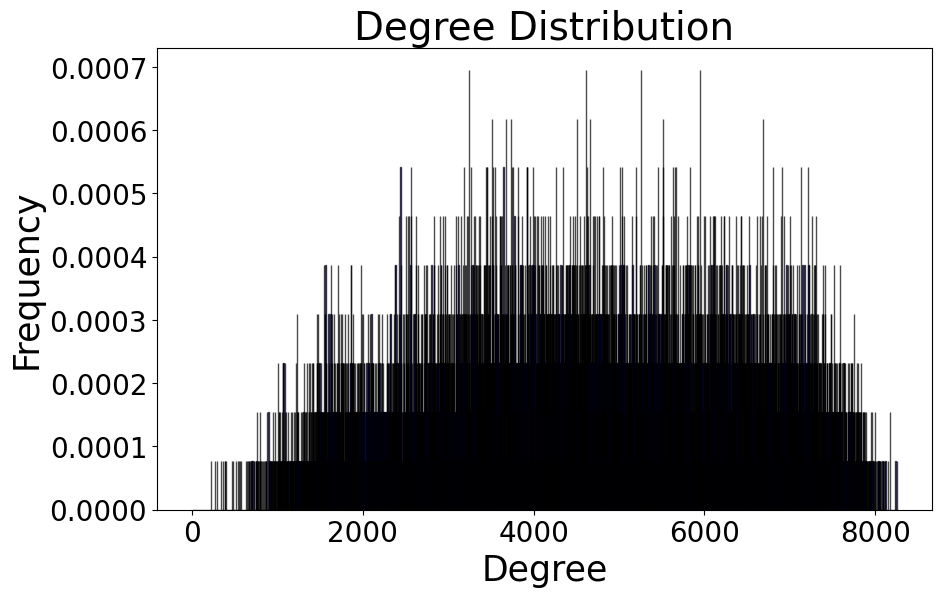

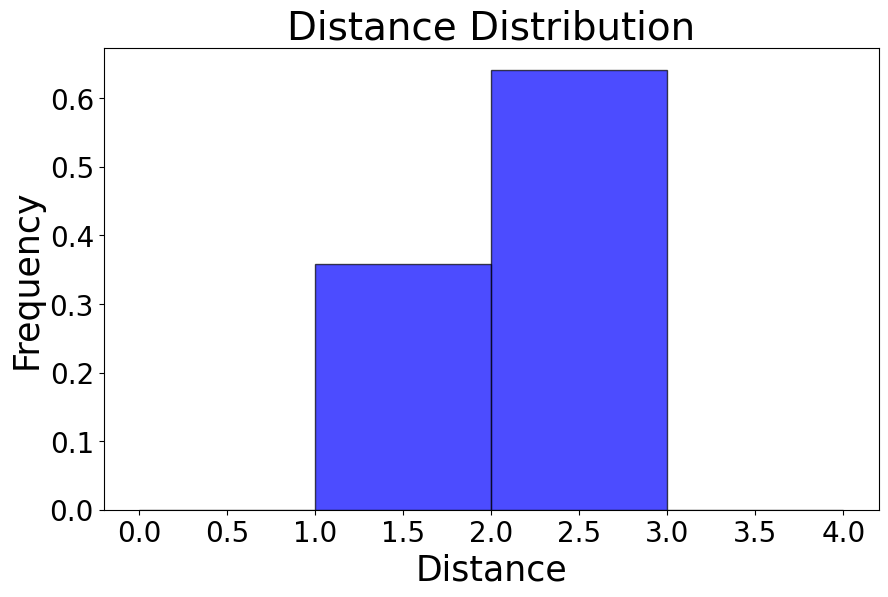

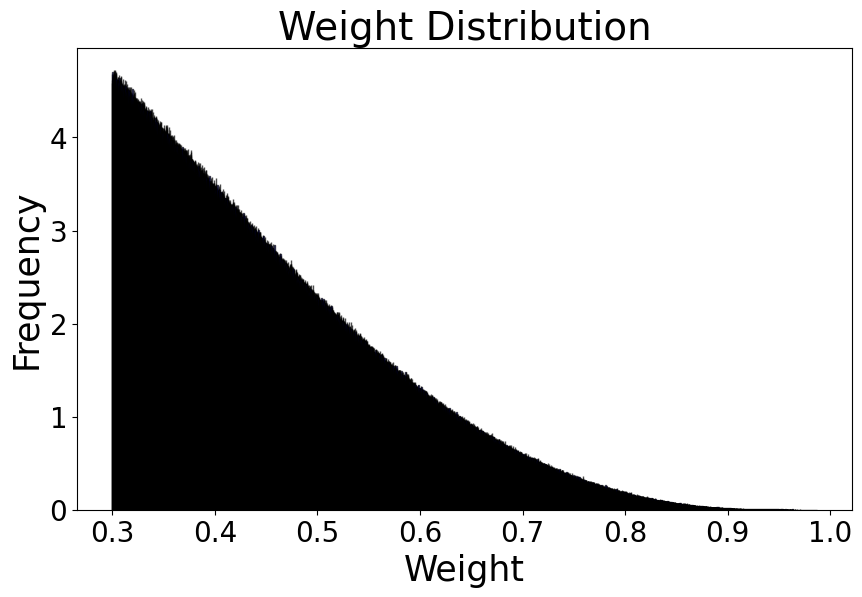

Number of clusters: 27
Number of modules: 21
IGRAPH UNW- 12939 30015384 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


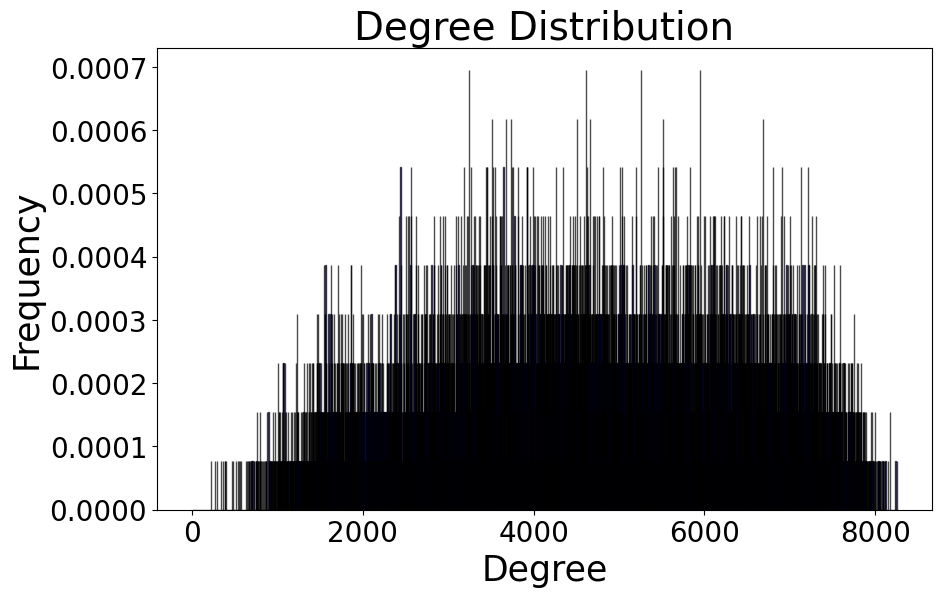

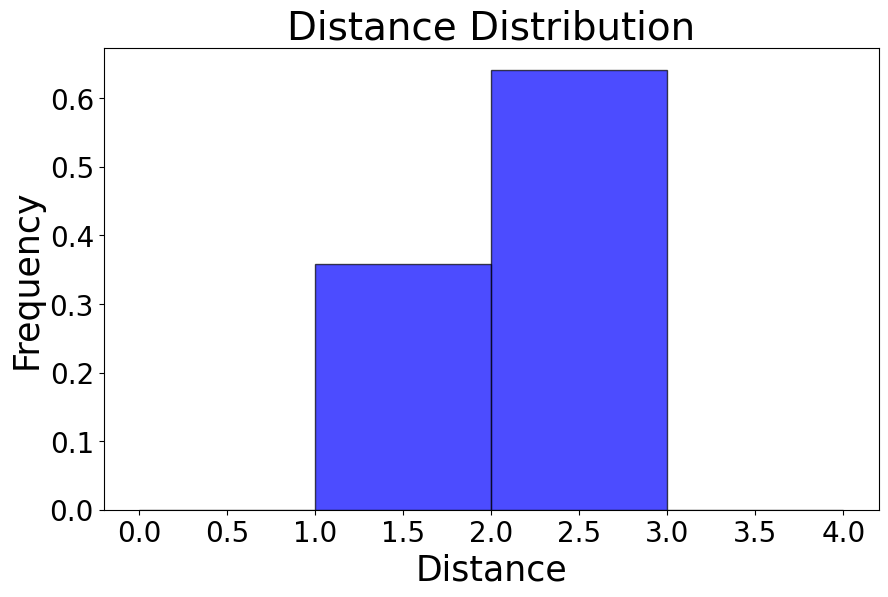

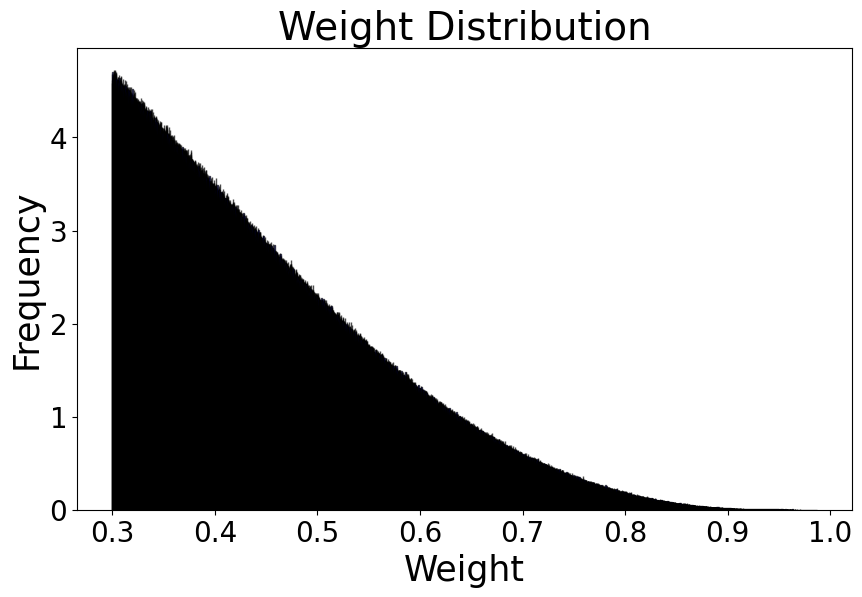

Number of clusters: 43
Number of modules: 32
IGRAPH UNW- 12939 30015384 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


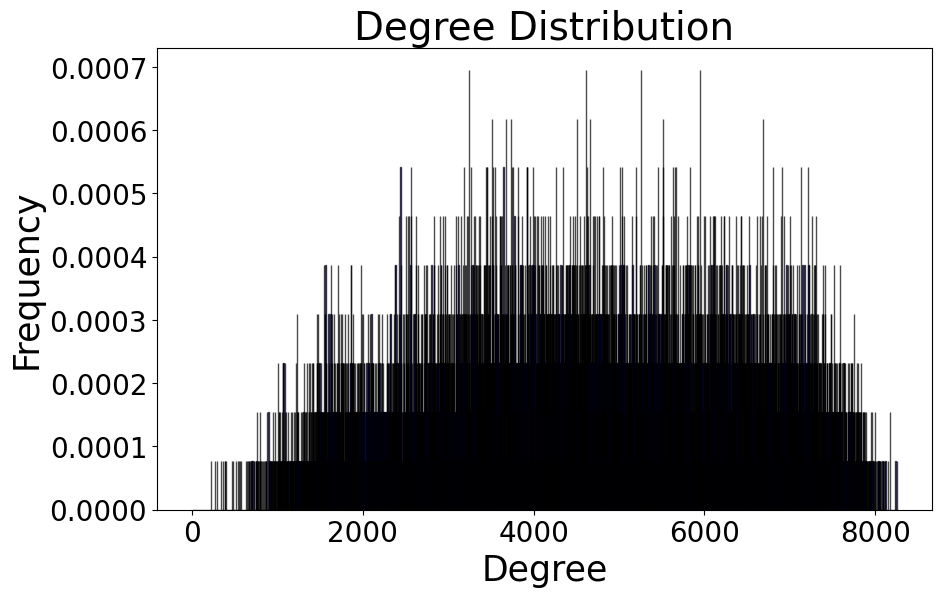

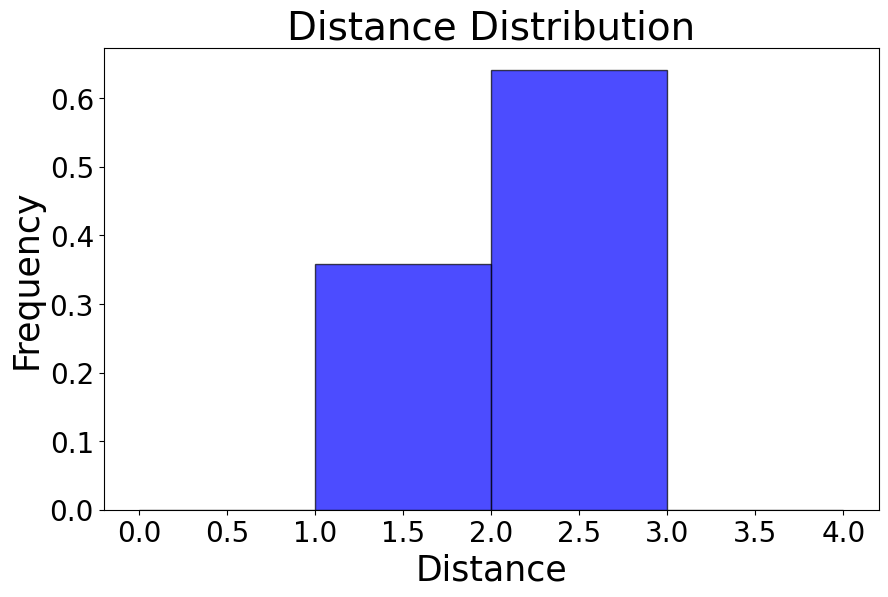

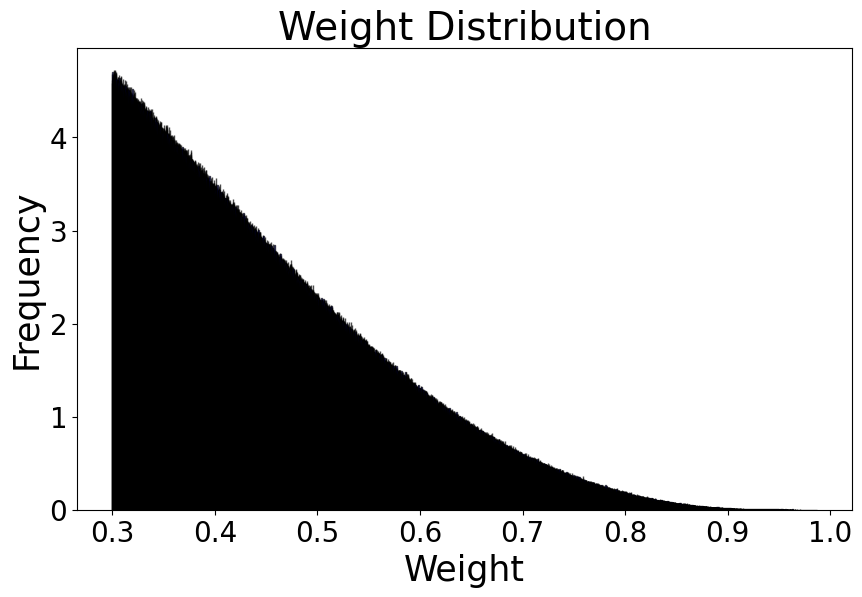

Number of clusters: 63
Number of modules: 52
IGRAPH UNW- 12939 30015384 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


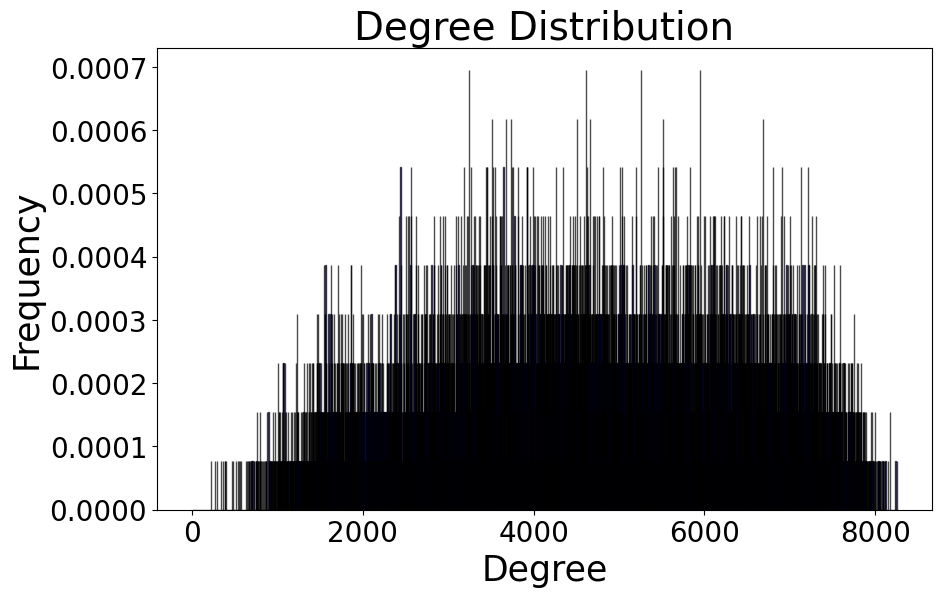

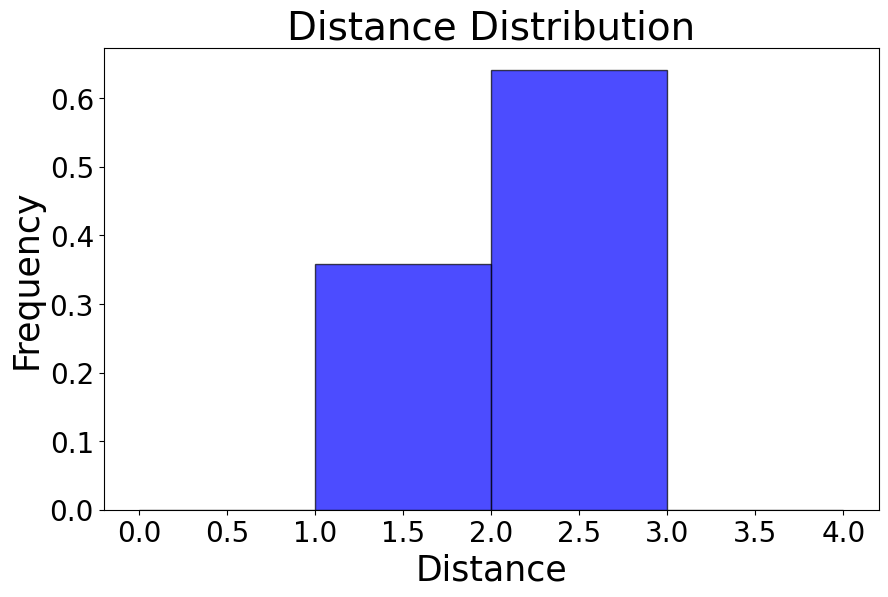

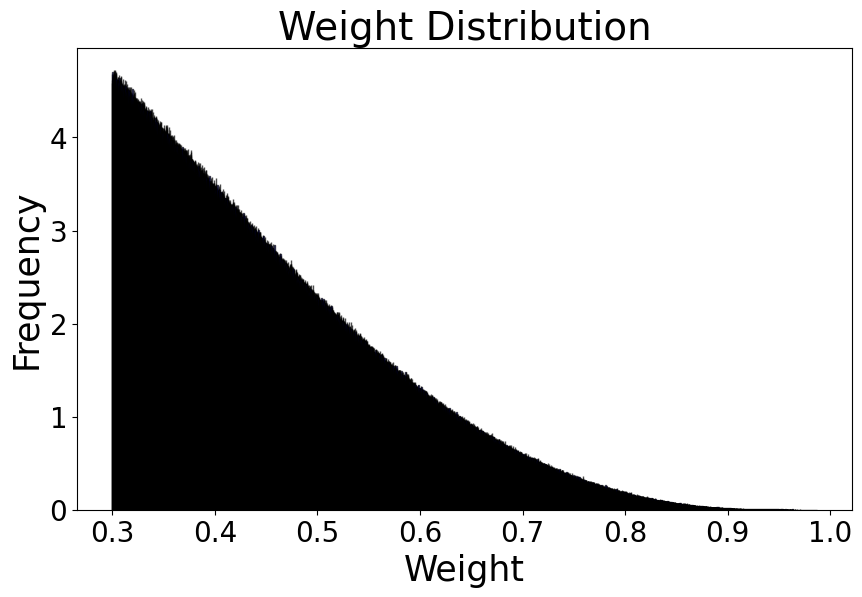

Number of clusters: 86
Number of modules: 70
IGRAPH UNW- 12939 30015384 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


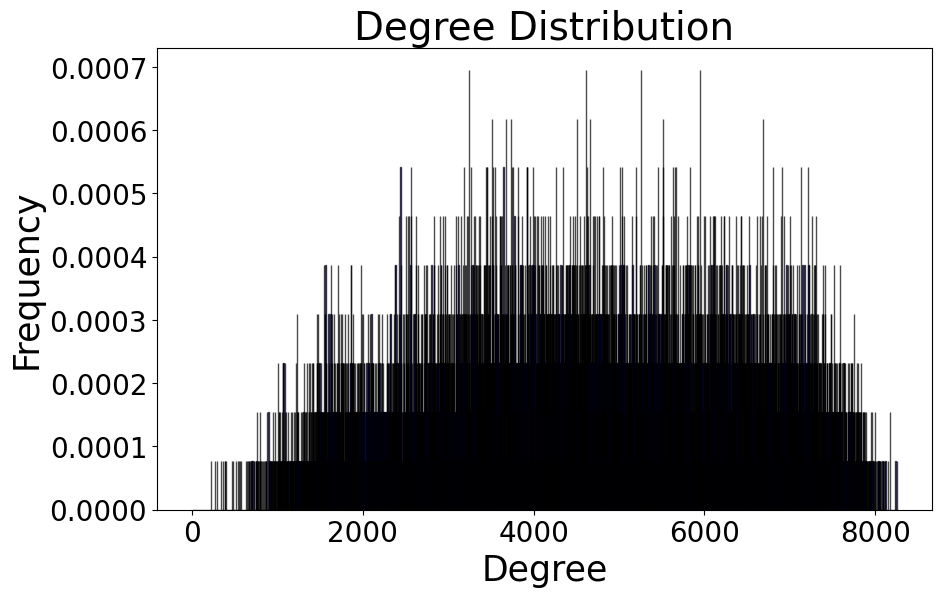

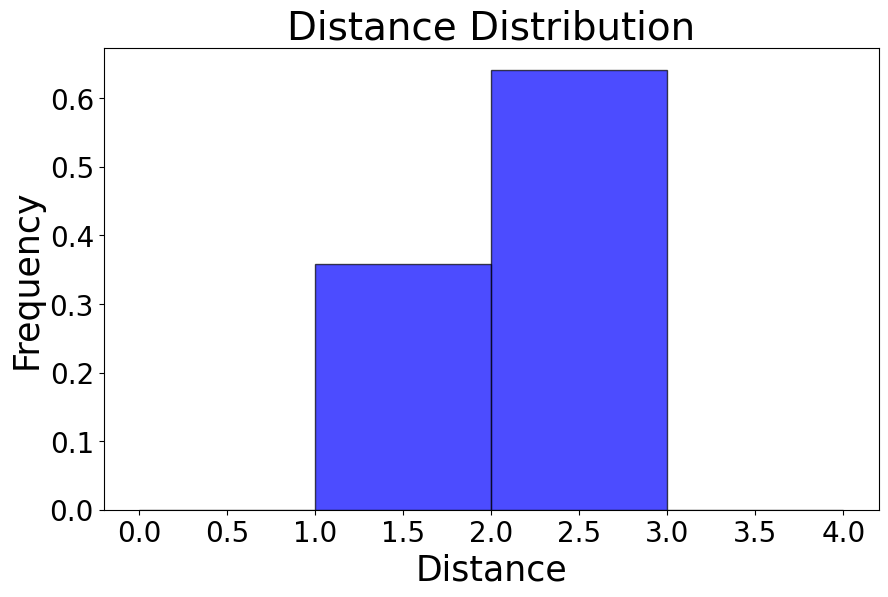

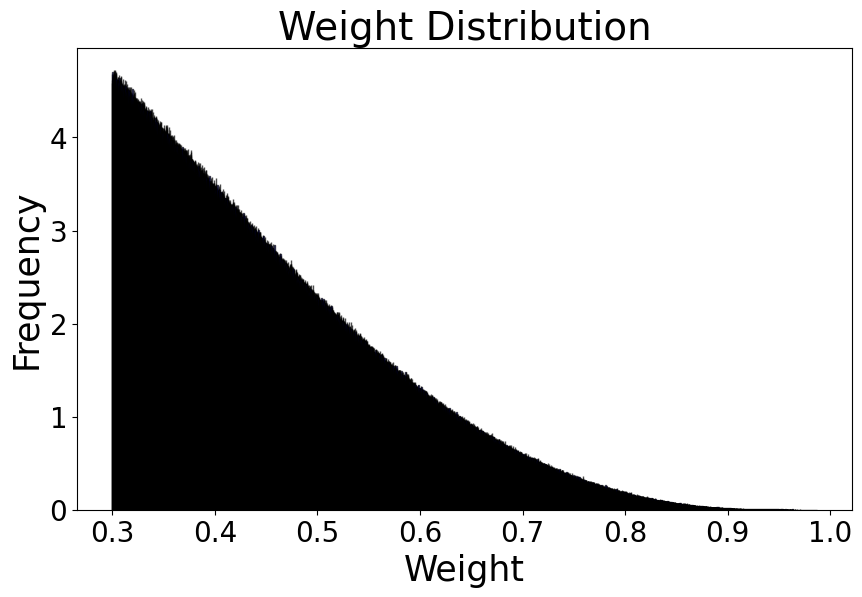

Number of clusters: 116
Number of modules: 96
IGRAPH UNW- 12939 30015384 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


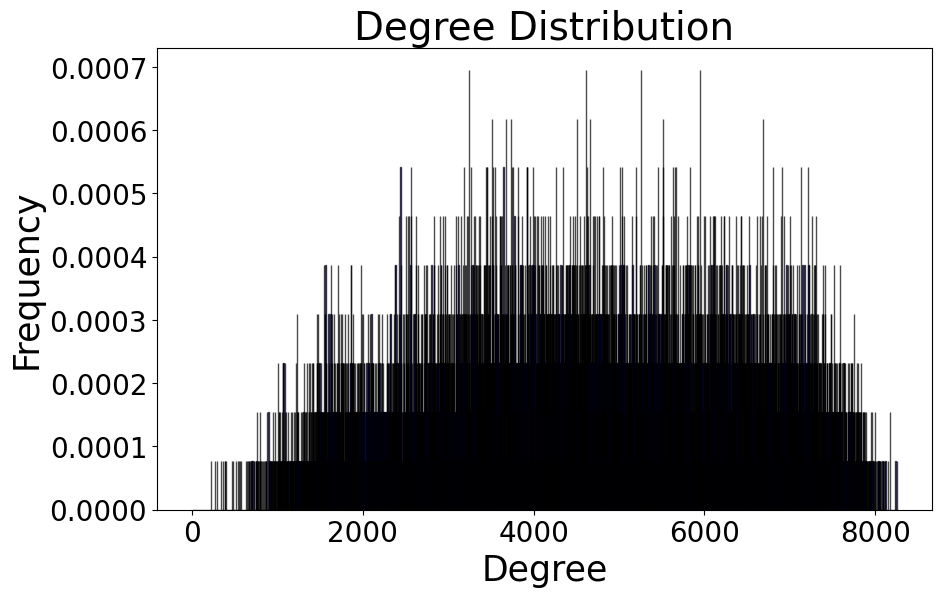

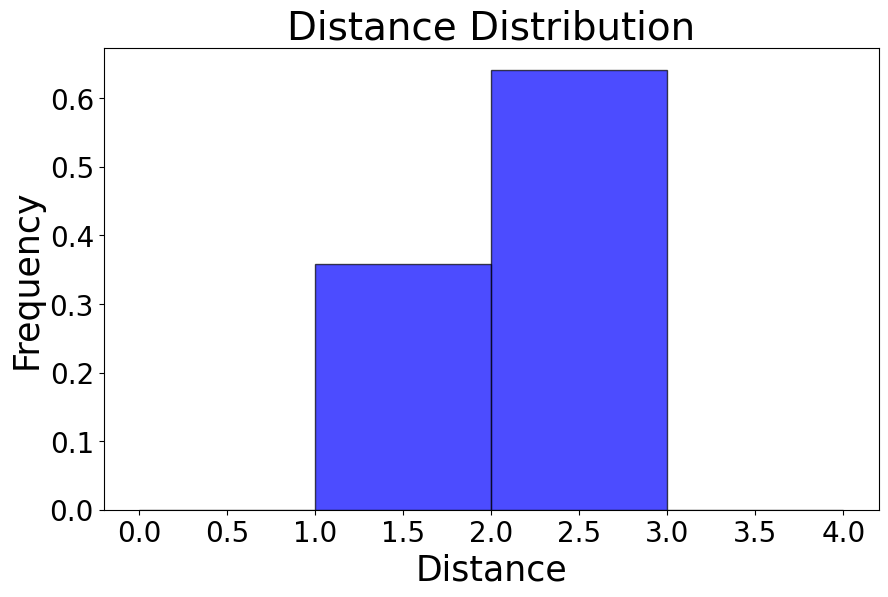

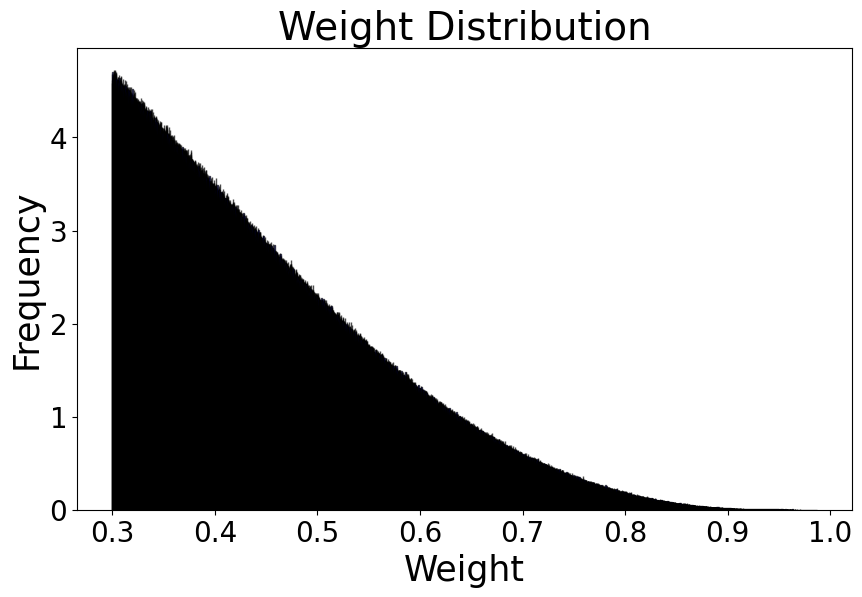

Number of clusters: 166
Number of modules: 131
IGRAPH UNW- 12939 30015384 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


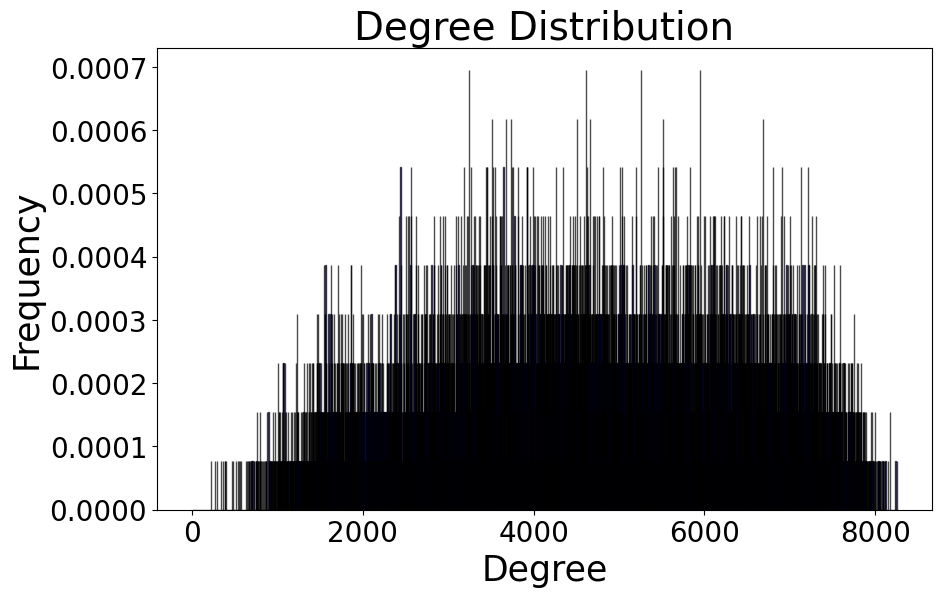

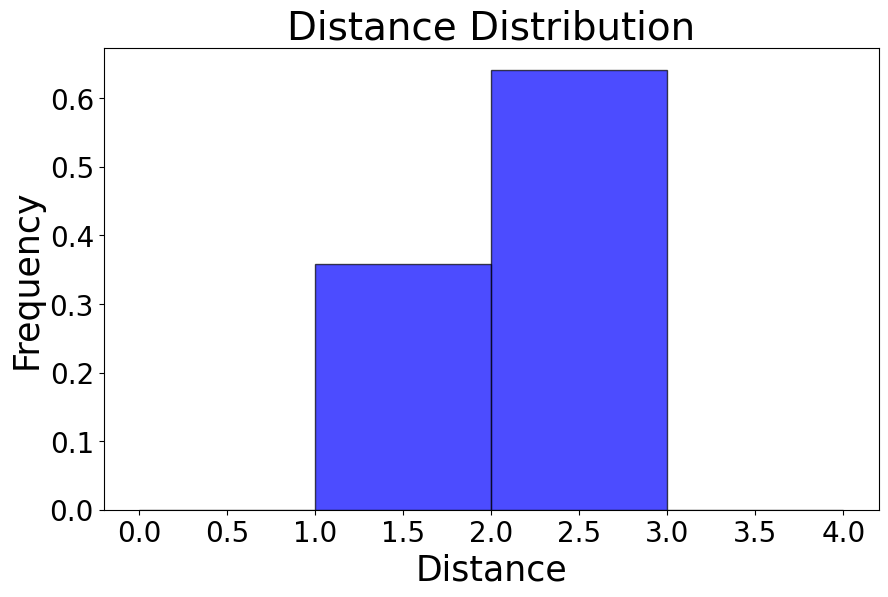

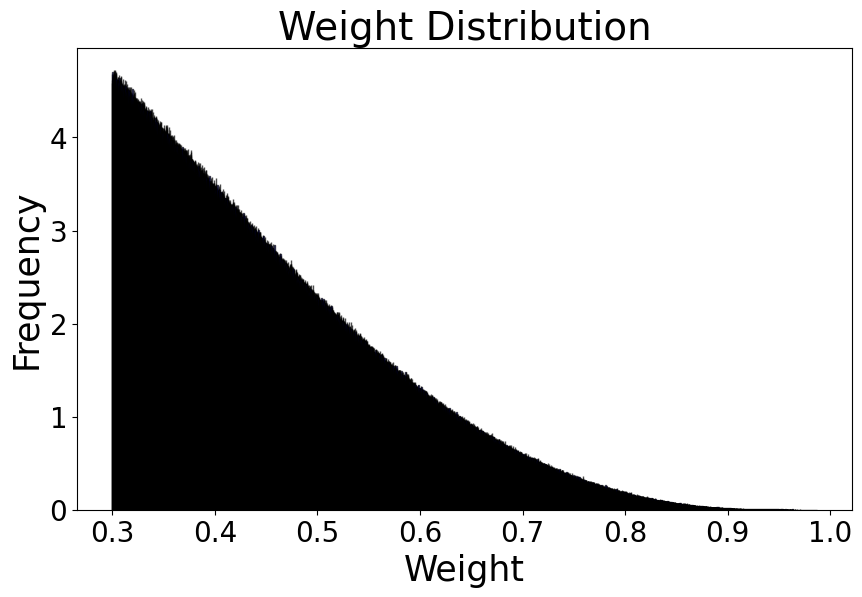

IOStream.flush timed out


Number of clusters: 226
Number of modules: 182
IGRAPH UNW- 12939 30015384 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


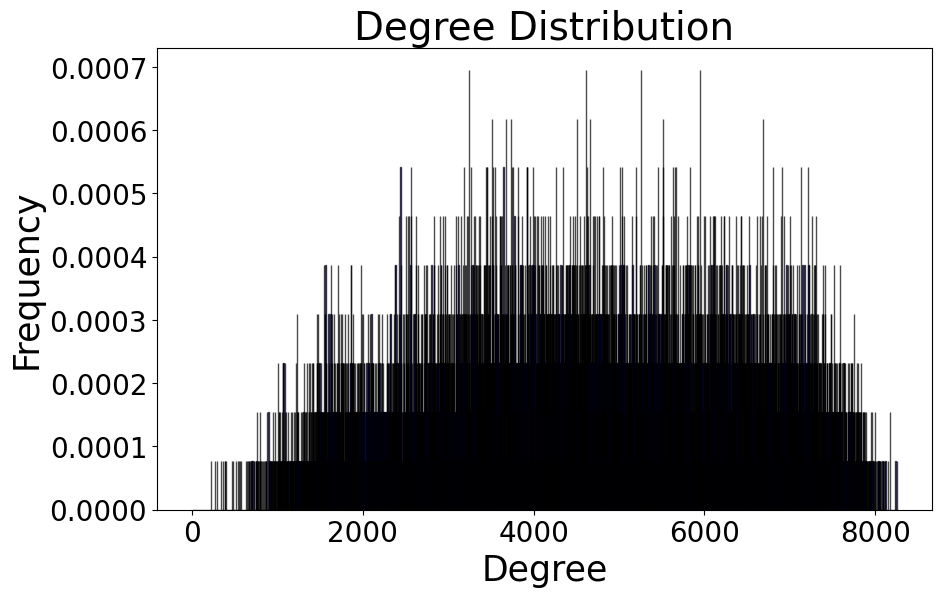

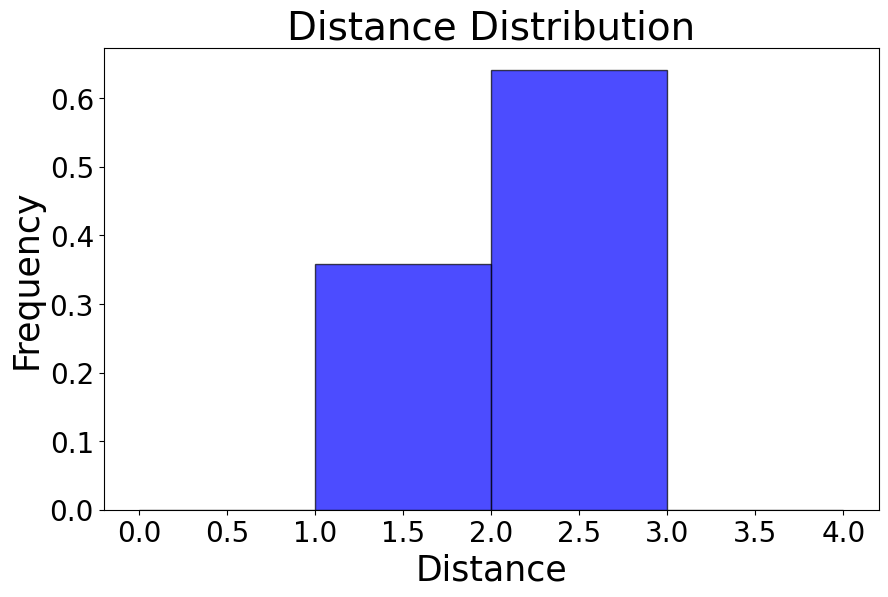

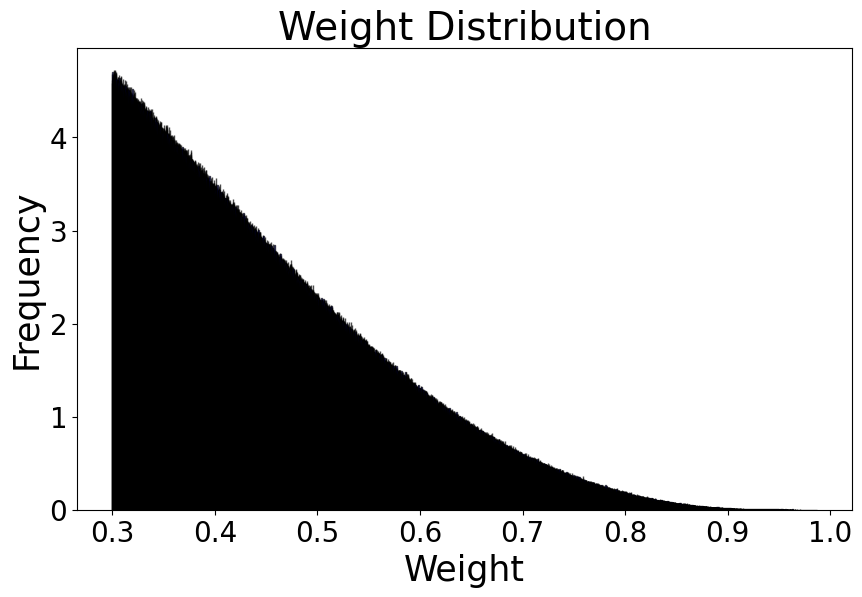

Number of clusters: 341
Number of modules: 240
IGRAPH UNW- 12939 30015384 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


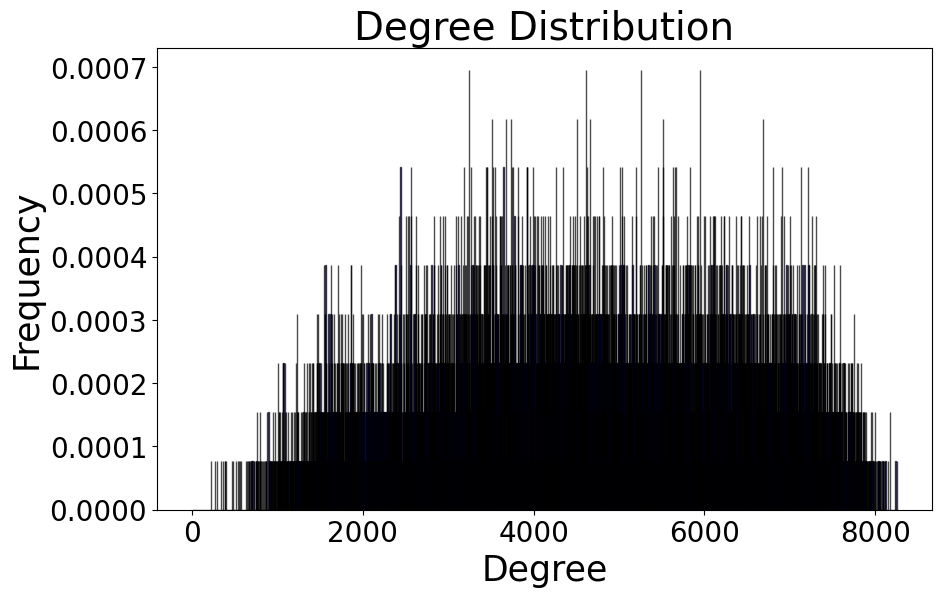

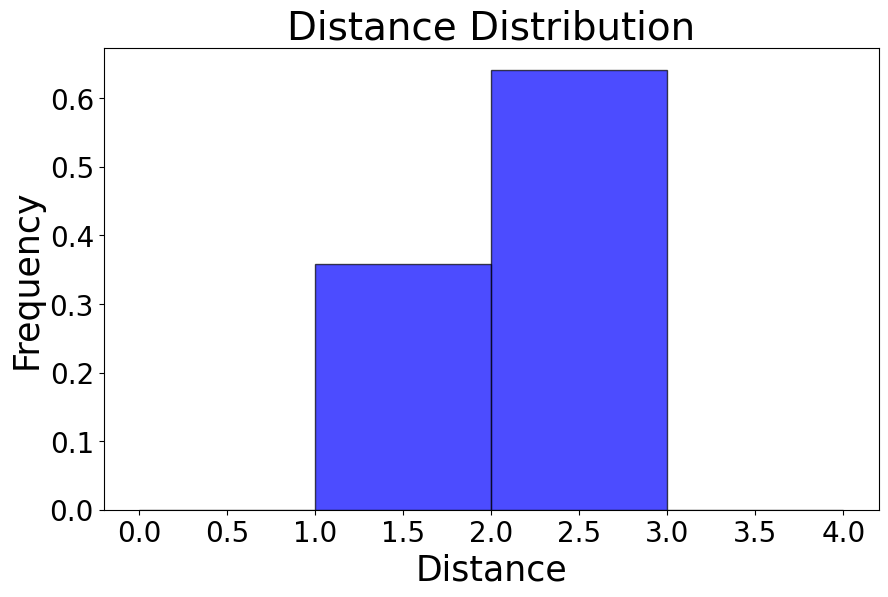

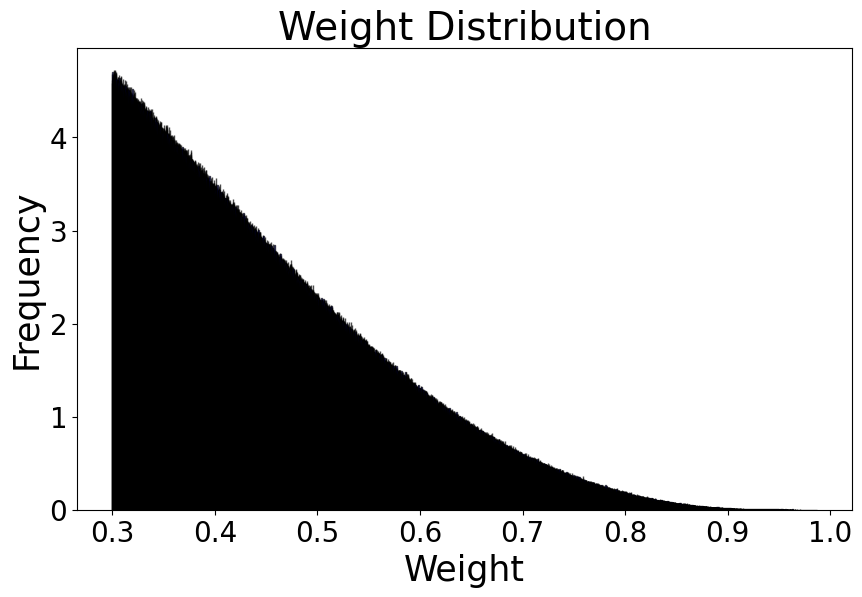

Number of clusters: 533
Number of modules: 332


In [7]:
resolution_values = [0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5]  # for pcc_threshold = 0.3: 20~330 modules

for resolution_parameter in resolution_values:
    module_4S = Leiden_pcc_to_module(pcc_matrix=pcc_4S, fig_path1=f"./figures/degree_distribution_4S_{resolution_parameter}.svg", fig_path2=f"./figures/distance_distribution_4S_{resolution_parameter}.svg", fig_path3=f"./figures/weight_distribution_4S_{resolution_parameter}.svg", pcc_threshold=0.3, resolution_parameter=resolution_parameter, seed=123456)
    module_to_json(module_dict=module_4S, file_path=f"module_4S_{resolution_parameter}.json")

IGRAPH UNW- 12939 27911175 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


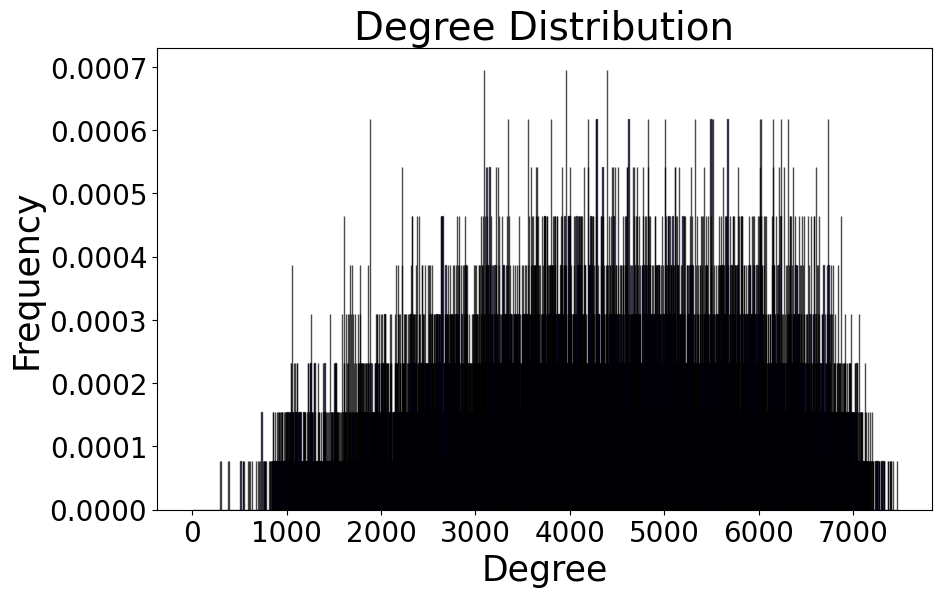

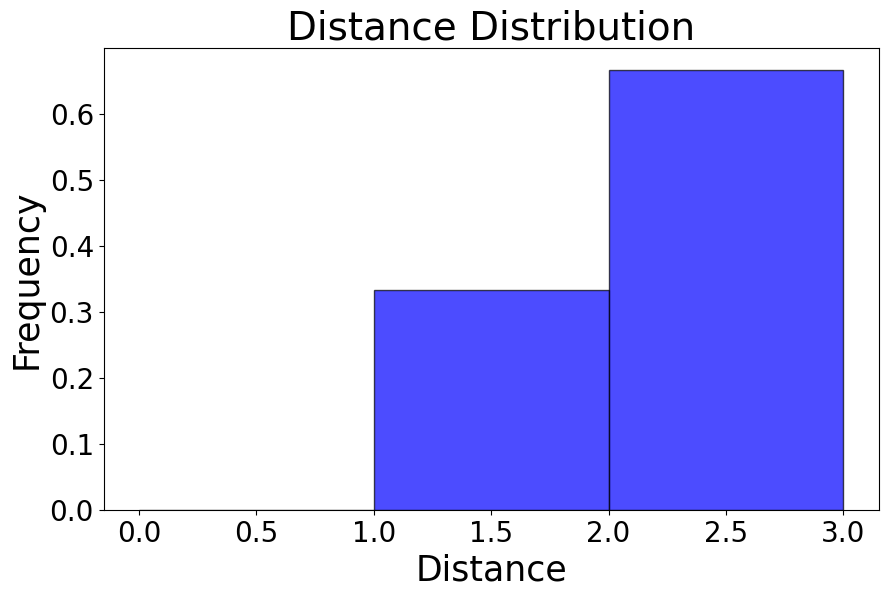

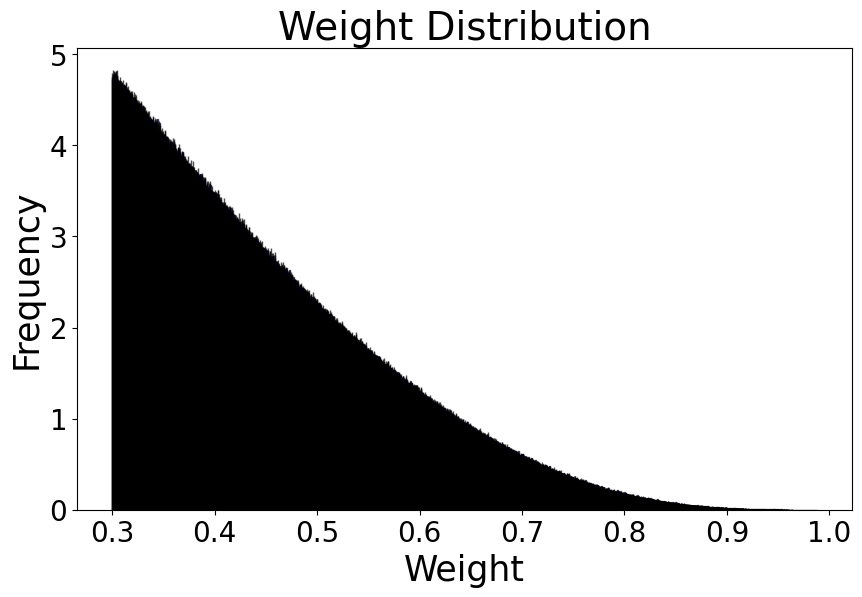

Number of clusters: 24
Number of modules: 21
IGRAPH UNW- 12939 27911175 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


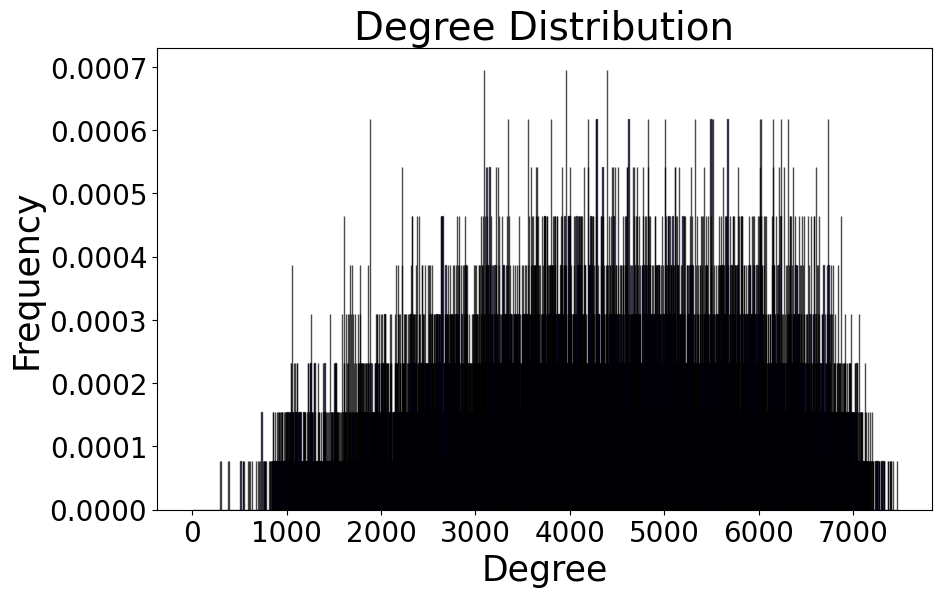

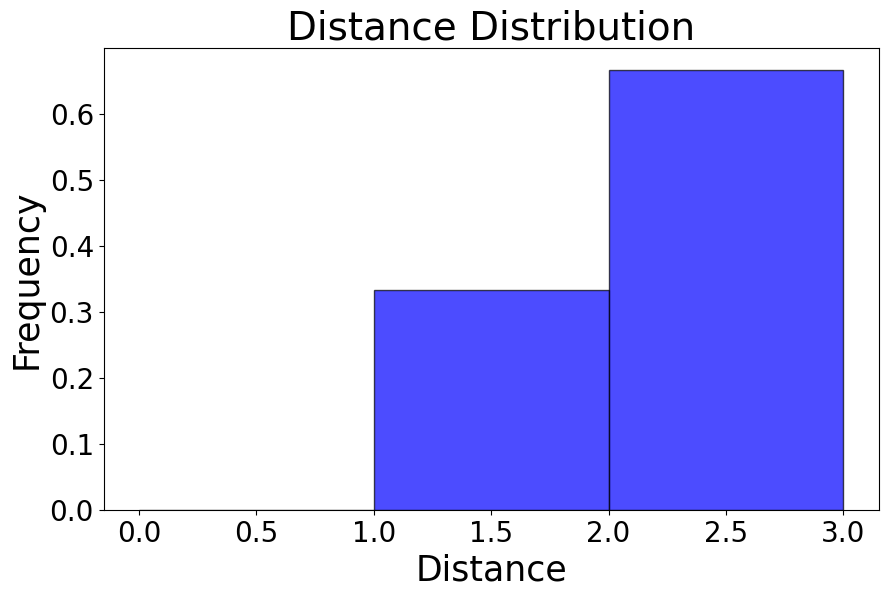

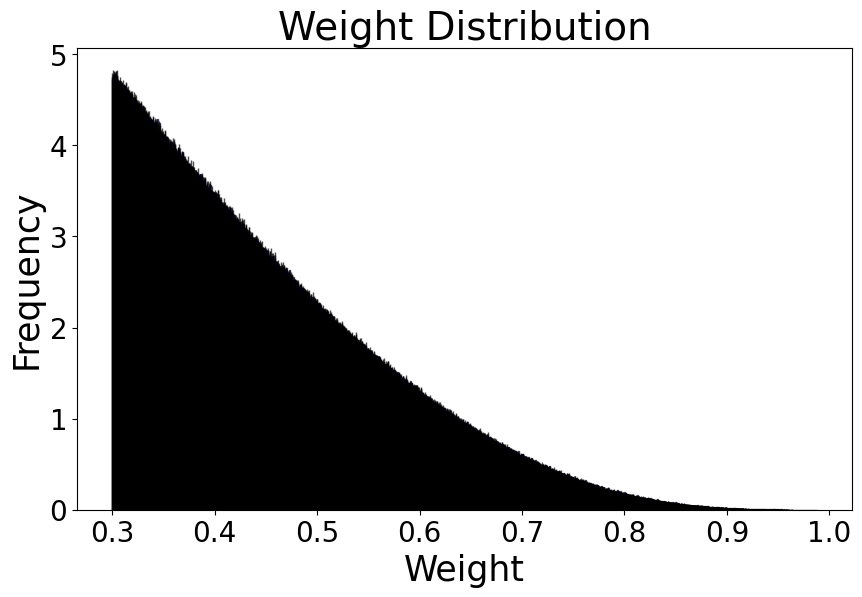

Number of clusters: 39
Number of modules: 33
IGRAPH UNW- 12939 27911175 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


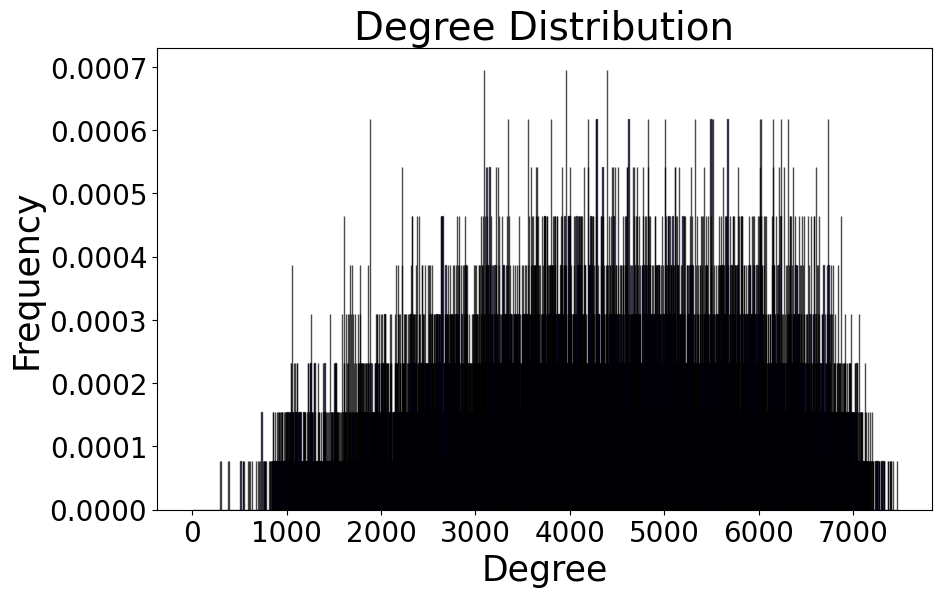

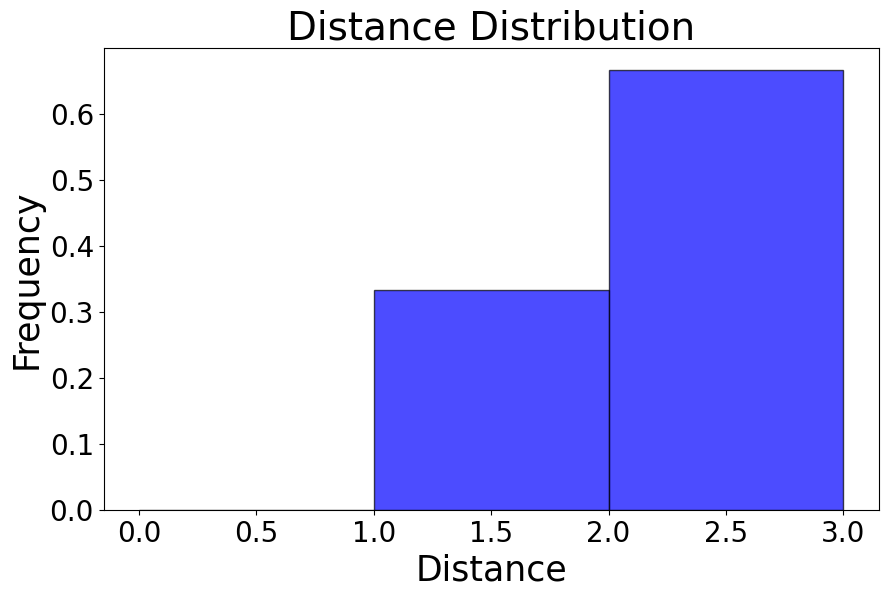

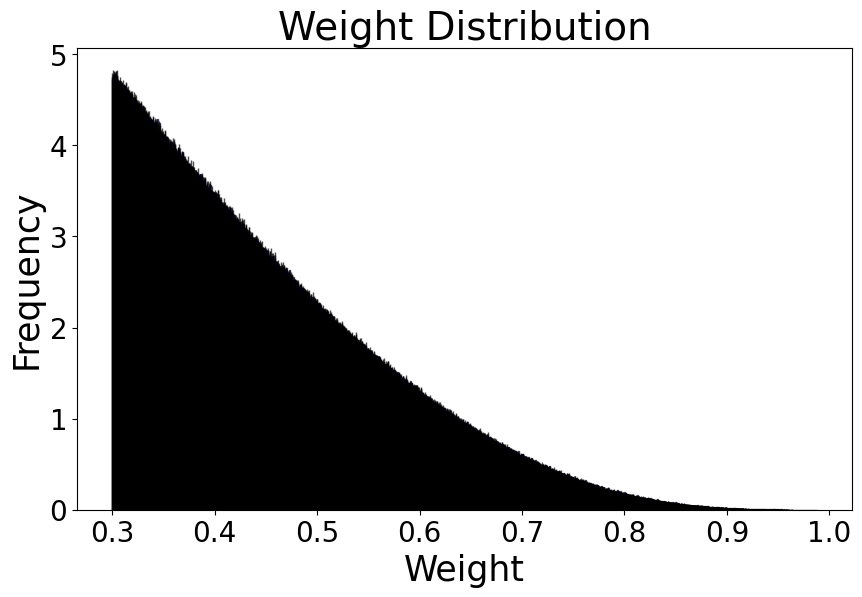

Number of clusters: 60
Number of modules: 49
IGRAPH UNW- 12939 27911175 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


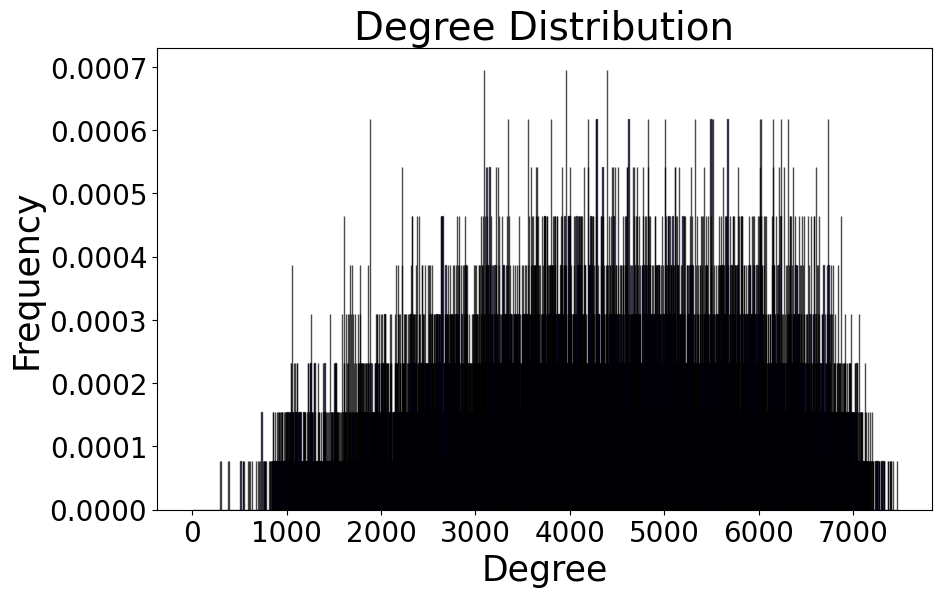

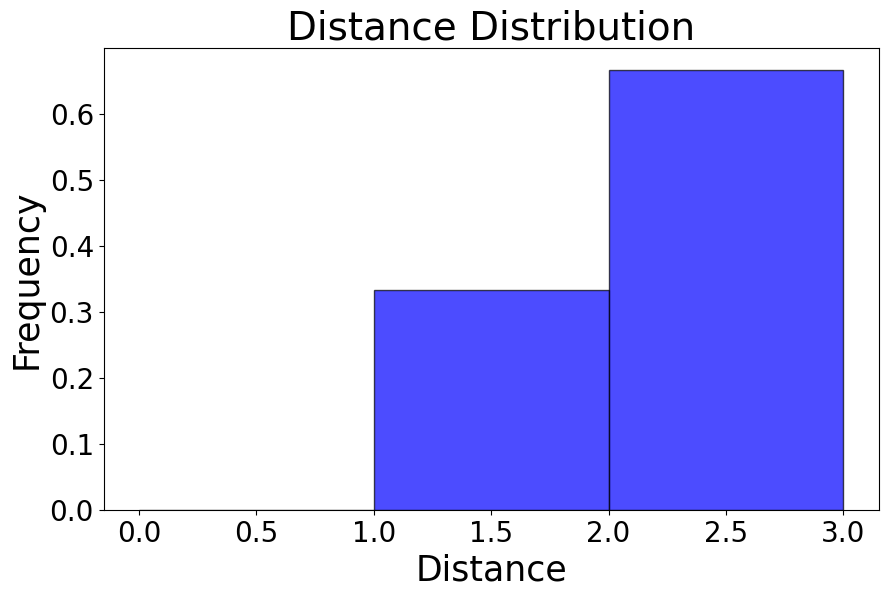

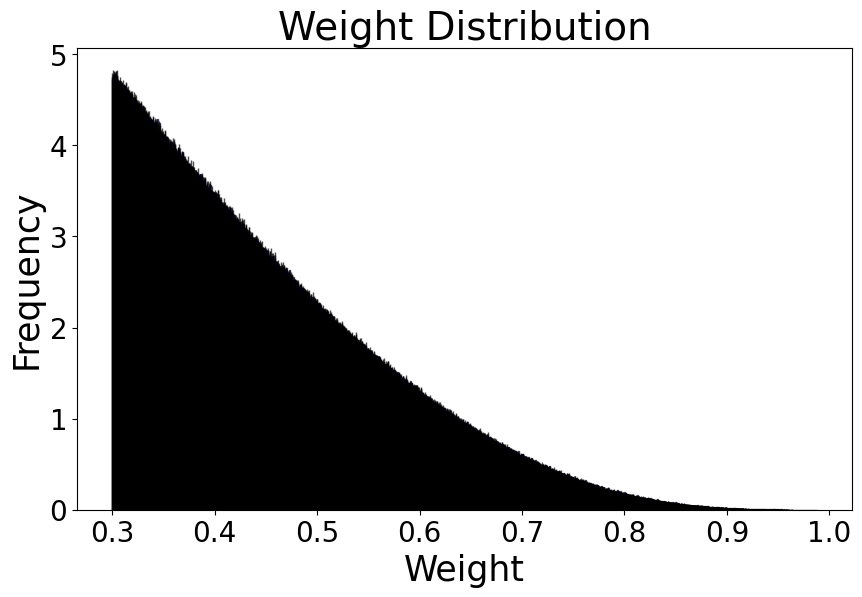

Number of clusters: 87
Number of modules: 66
IGRAPH UNW- 12939 27911175 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


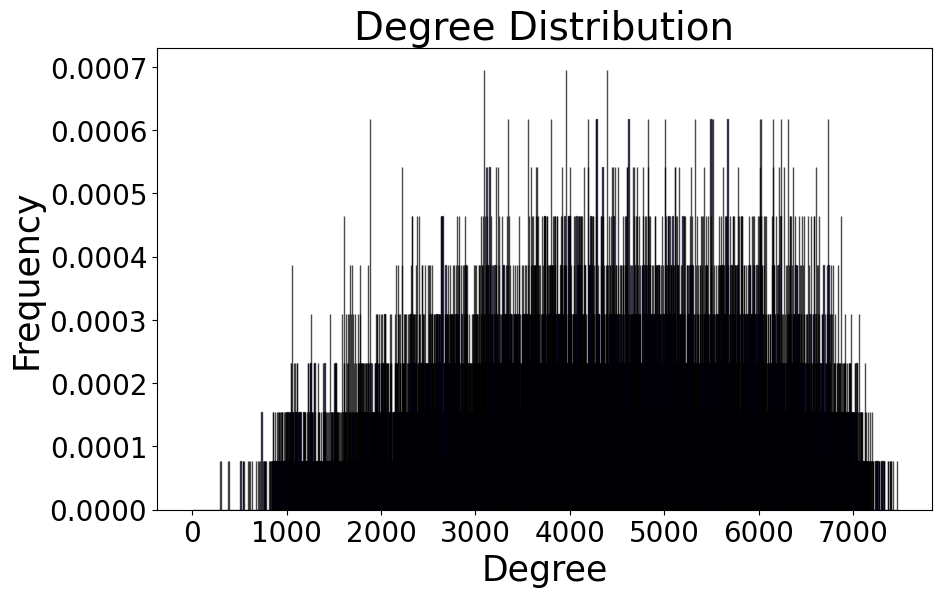

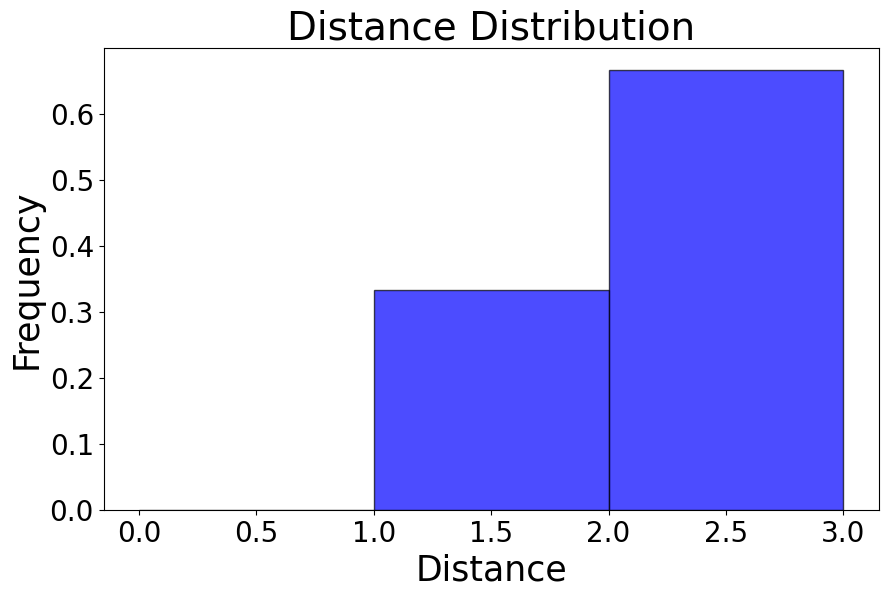

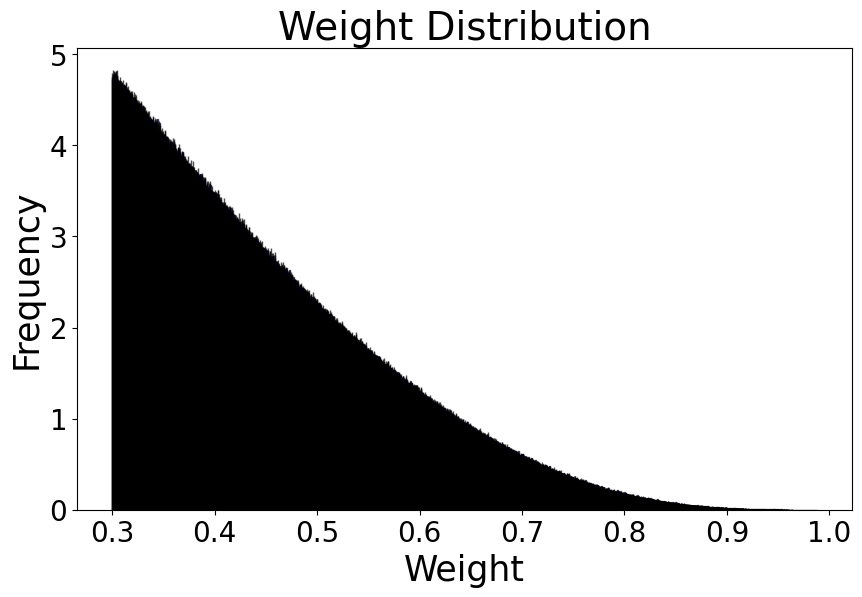

Number of clusters: 120
Number of modules: 94
IGRAPH UNW- 12939 27911175 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


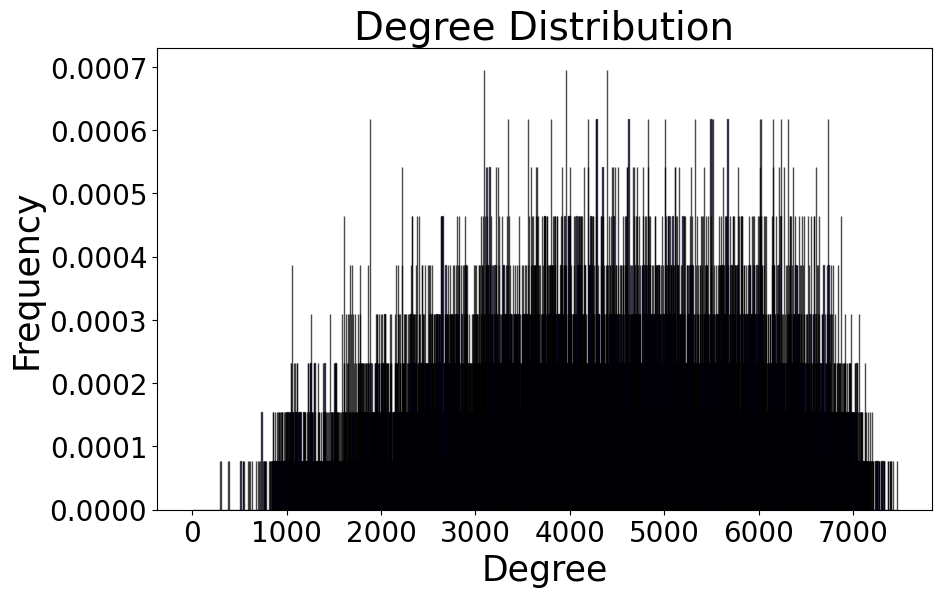

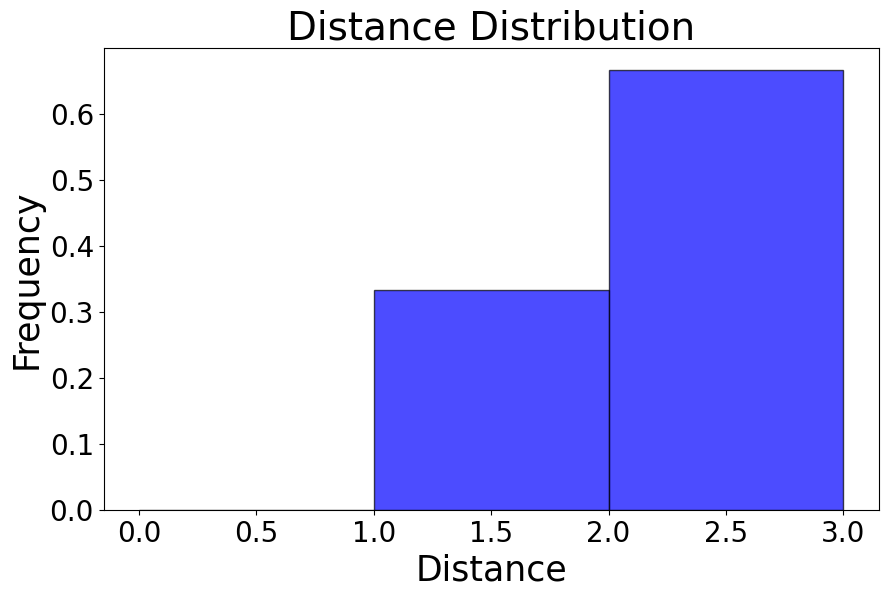

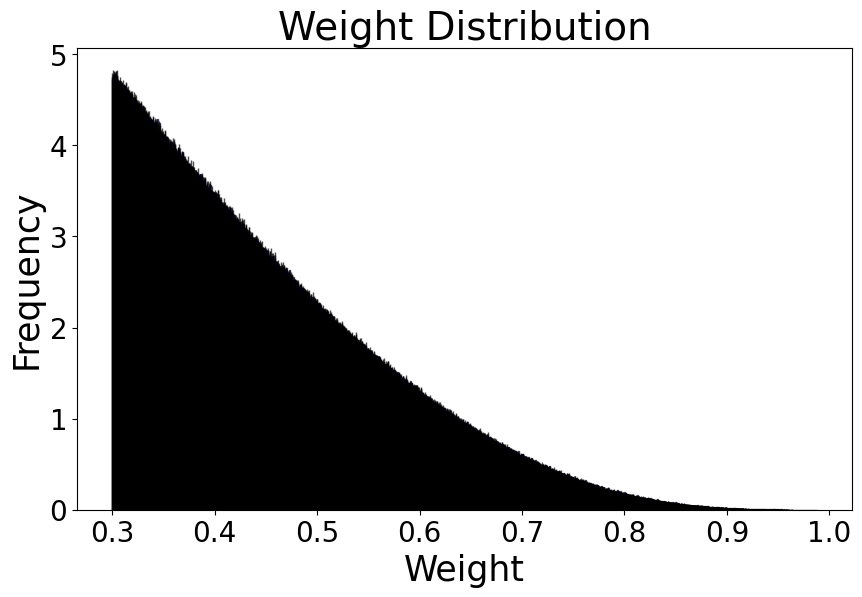

Number of clusters: 155
Number of modules: 130
IGRAPH UNW- 12939 27911175 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


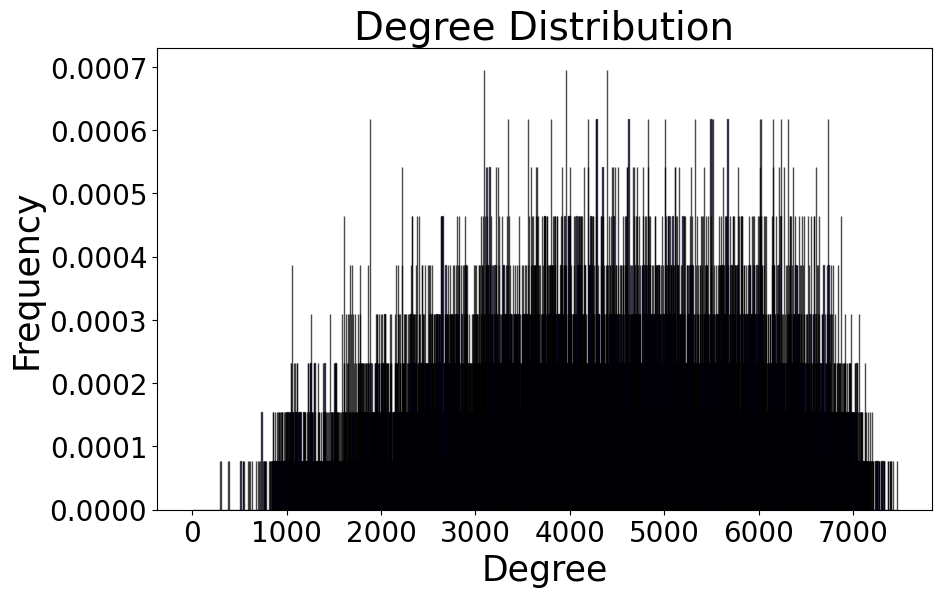

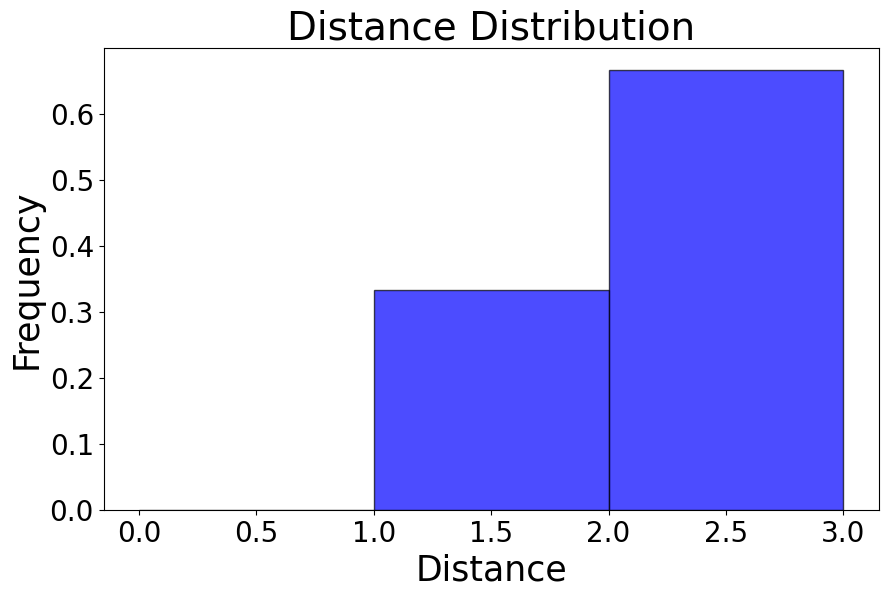

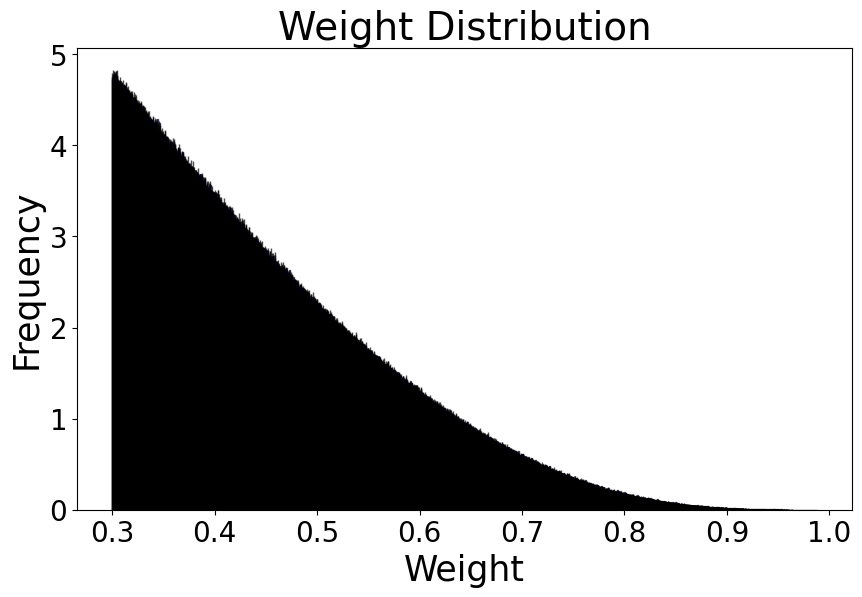

Number of clusters: 213
Number of modules: 163
IGRAPH UNW- 12939 27911175 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


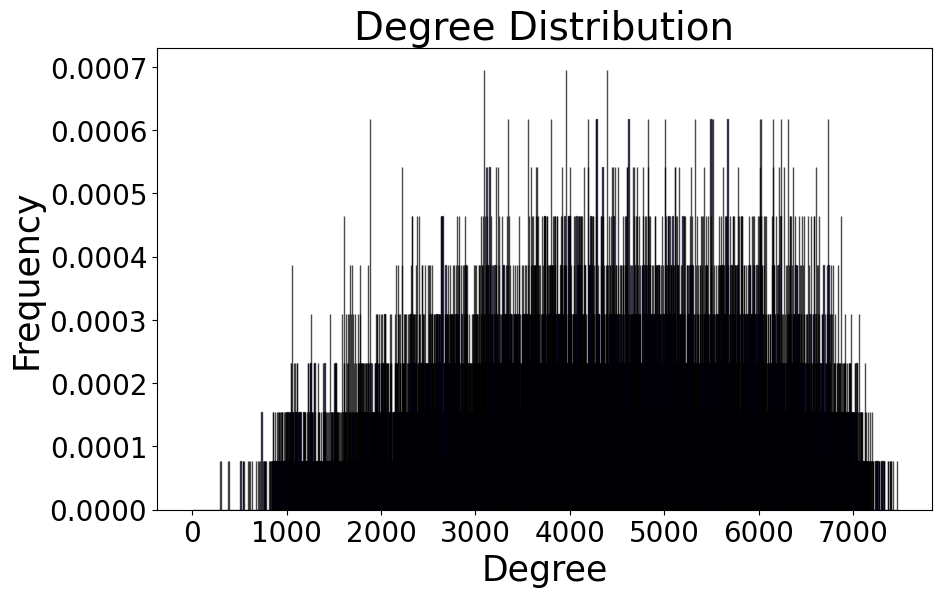

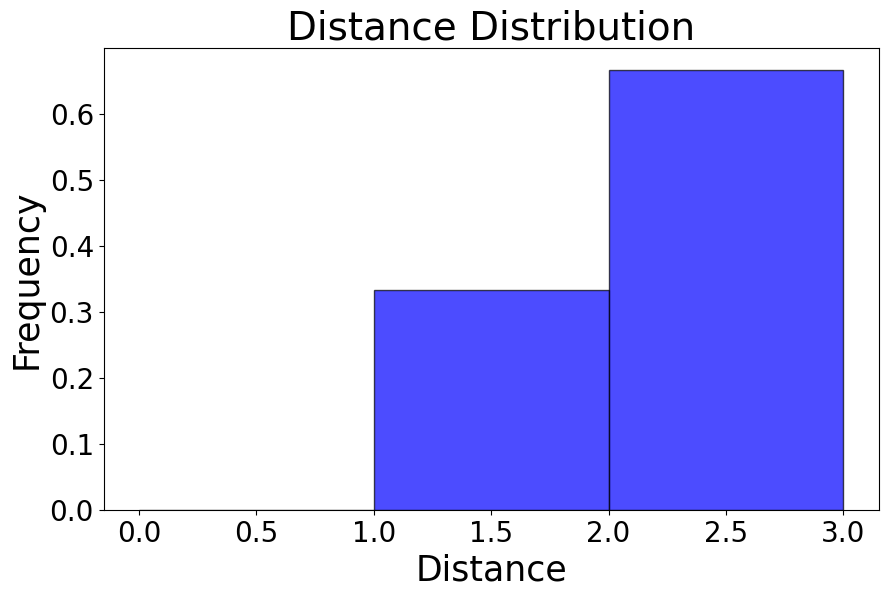

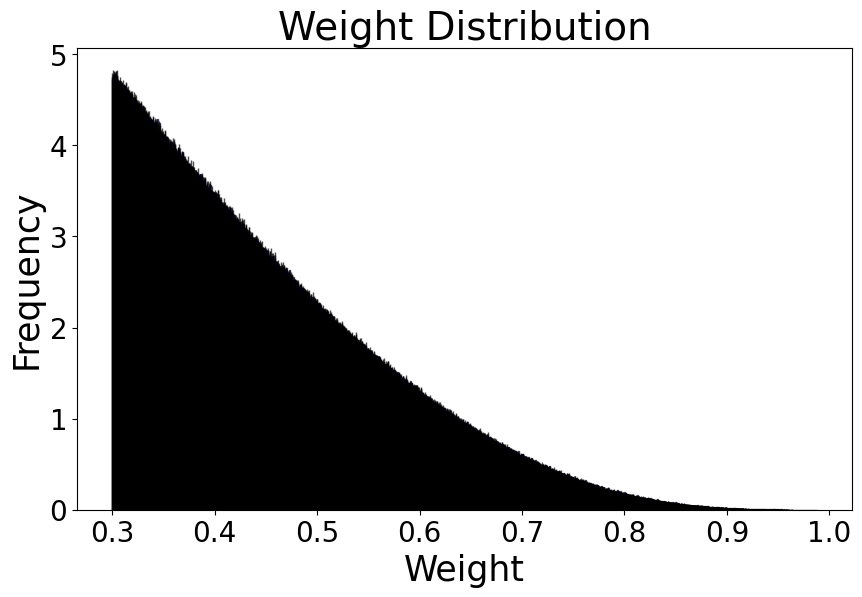

Number of clusters: 318
Number of modules: 227
IGRAPH UNW- 12939 27911175 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


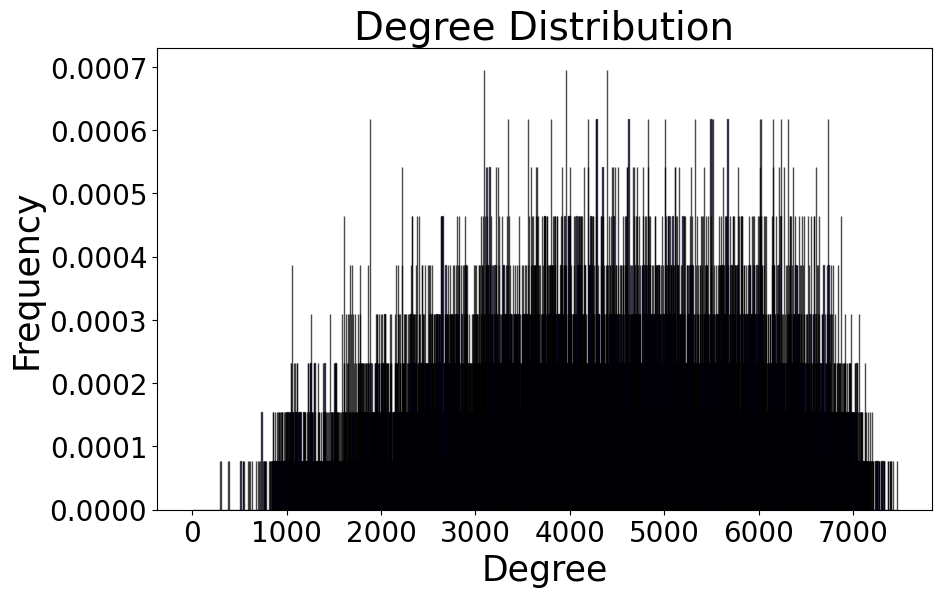

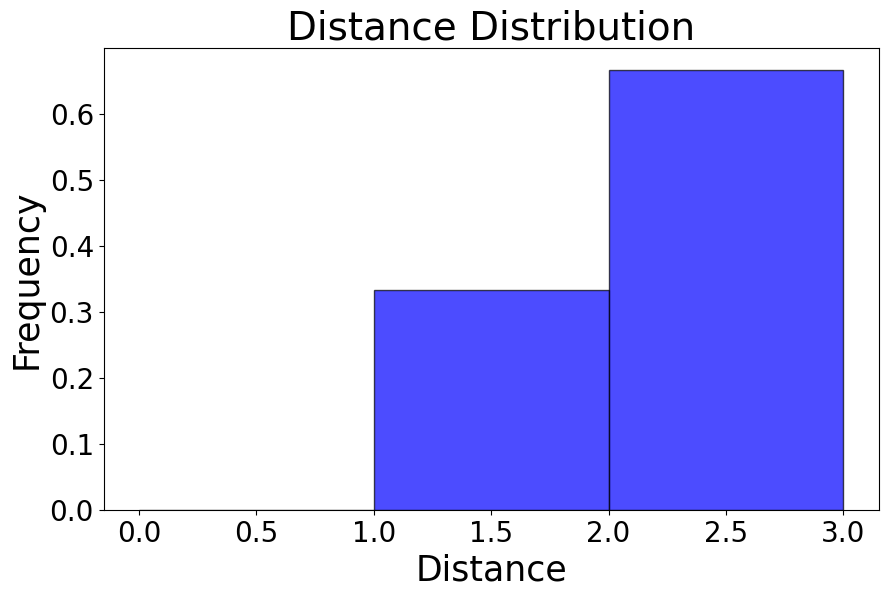

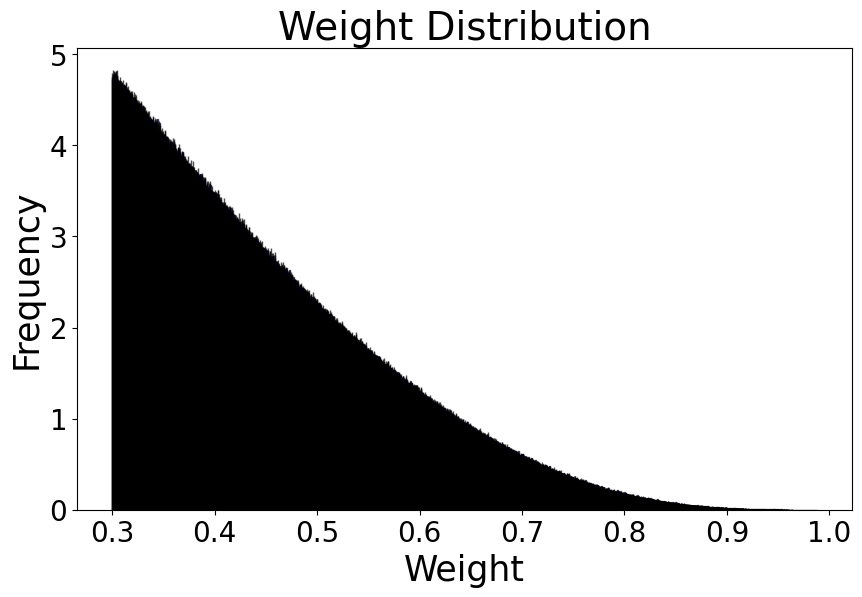

Number of clusters: 500
Number of modules: 315


In [8]:
for resolution_parameter in resolution_values:
    module_I = Leiden_pcc_to_module(pcc_matrix=pcc_I, fig_path1=f"./figures/degree_distribution_I_{resolution_parameter}.svg", fig_path2=f"./figures/distance_distribution_I_{resolution_parameter}.svg", fig_path3=f"./figures/weight_distribution_I_{resolution_parameter}.svg", pcc_threshold=0.3, resolution_parameter=resolution_parameter, seed=123456)
    module_to_json(module_dict=module_I, file_path=f"module_I_{resolution_parameter}.json")

IGRAPH UNW- 12939 31980014 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


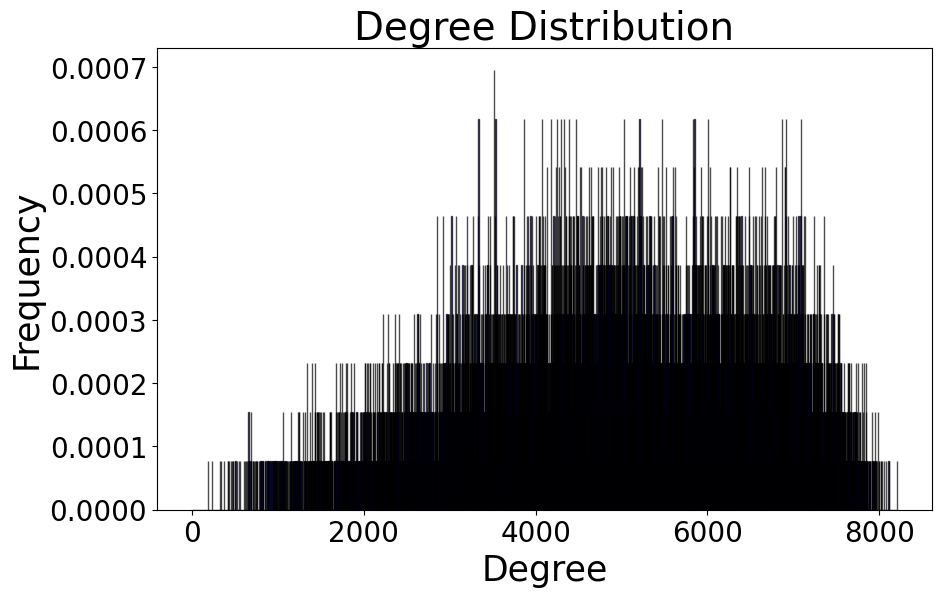

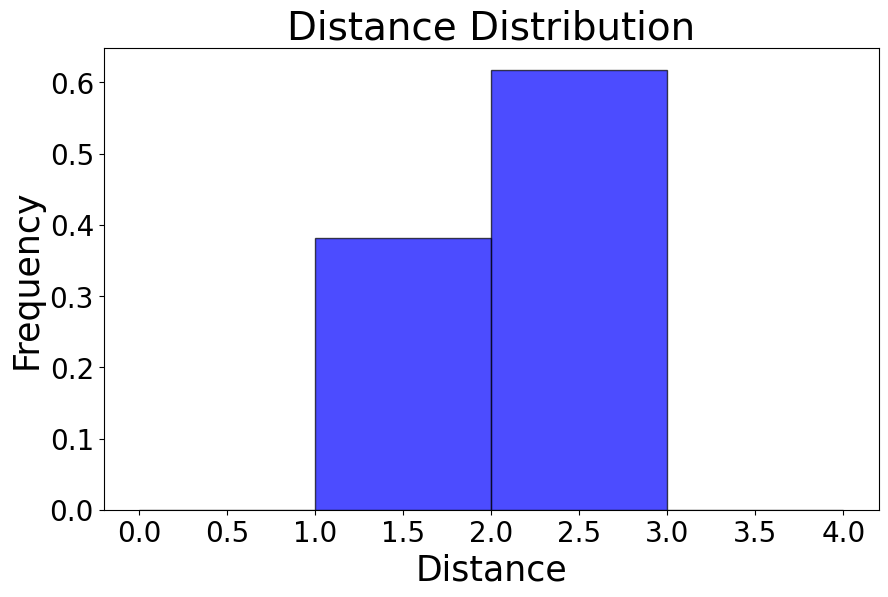

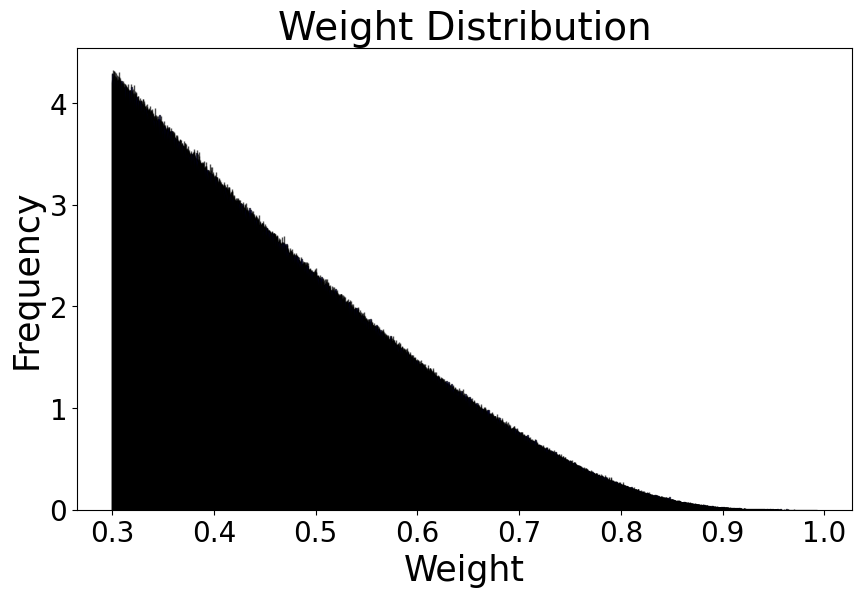

Number of clusters: 18
Number of modules: 15
IGRAPH UNW- 12939 31980014 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


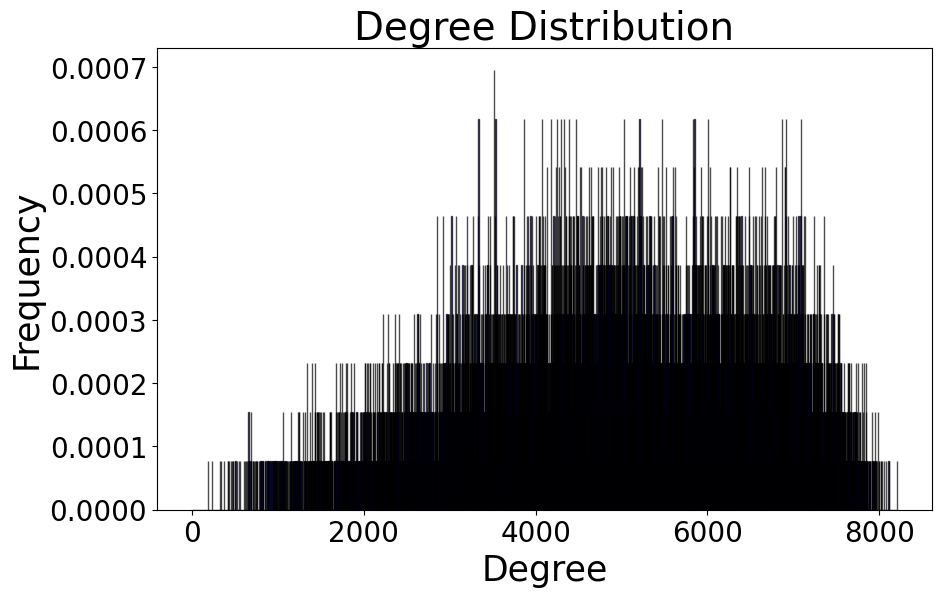

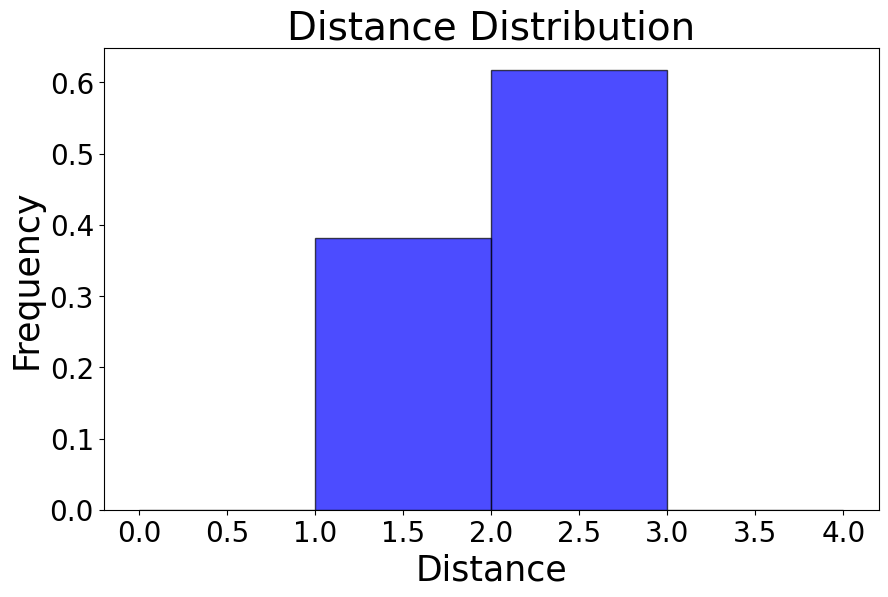

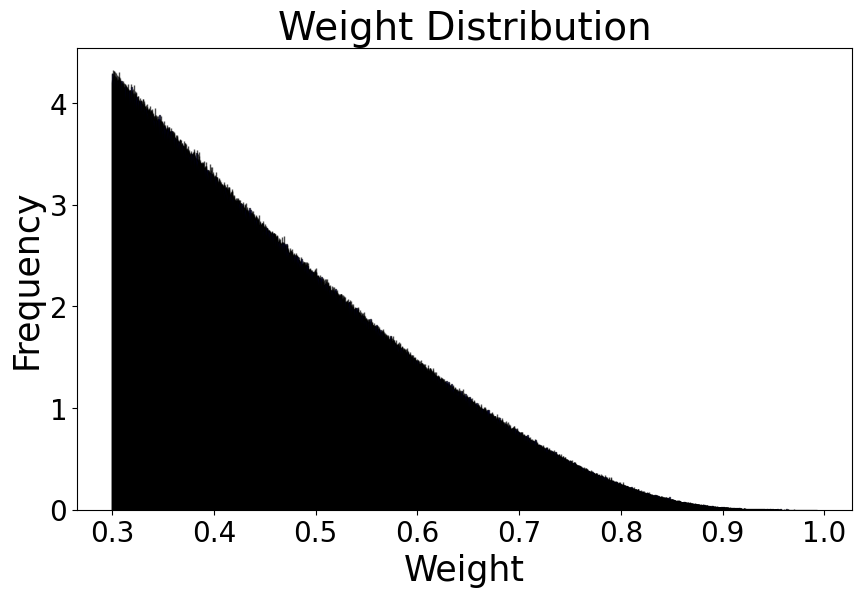

Number of clusters: 34
Number of modules: 24
IGRAPH UNW- 12939 31980014 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


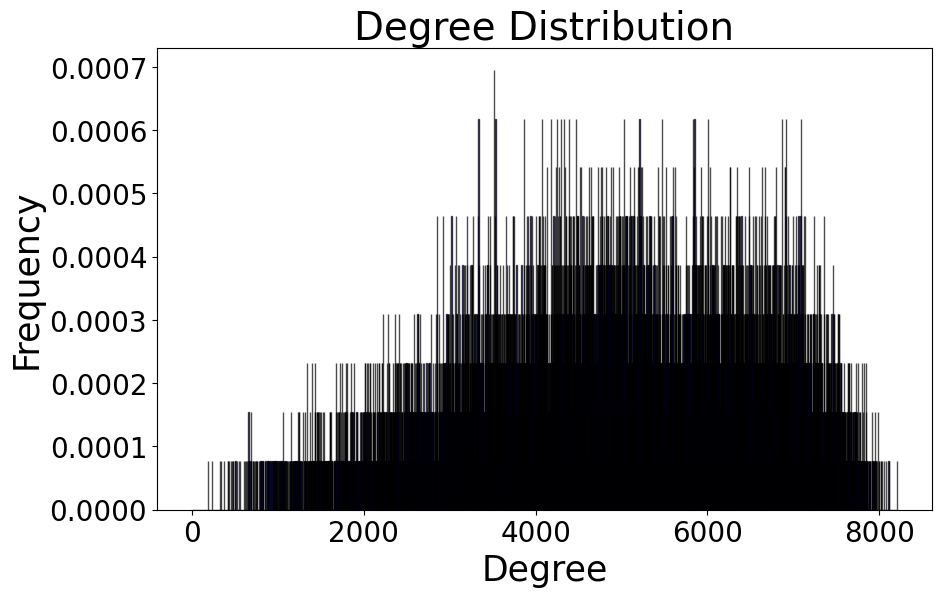

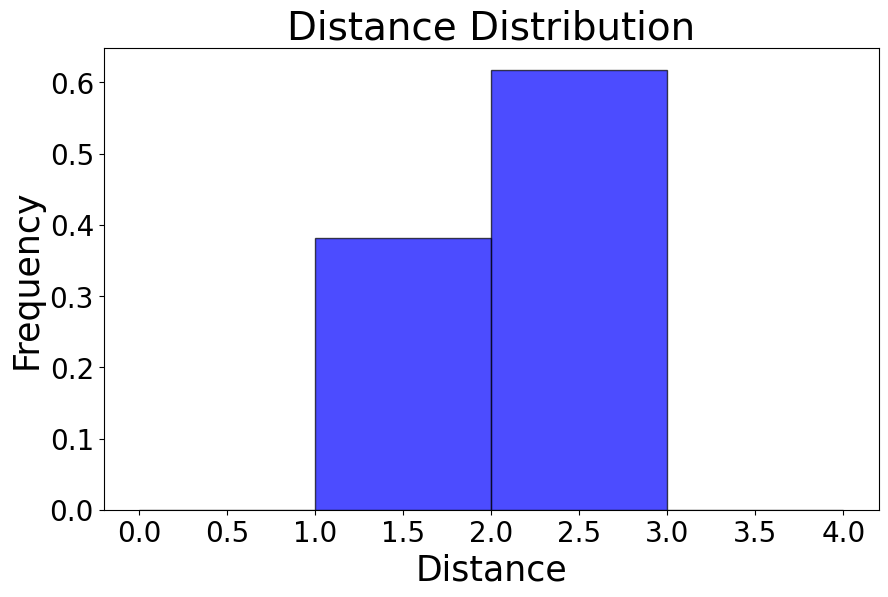

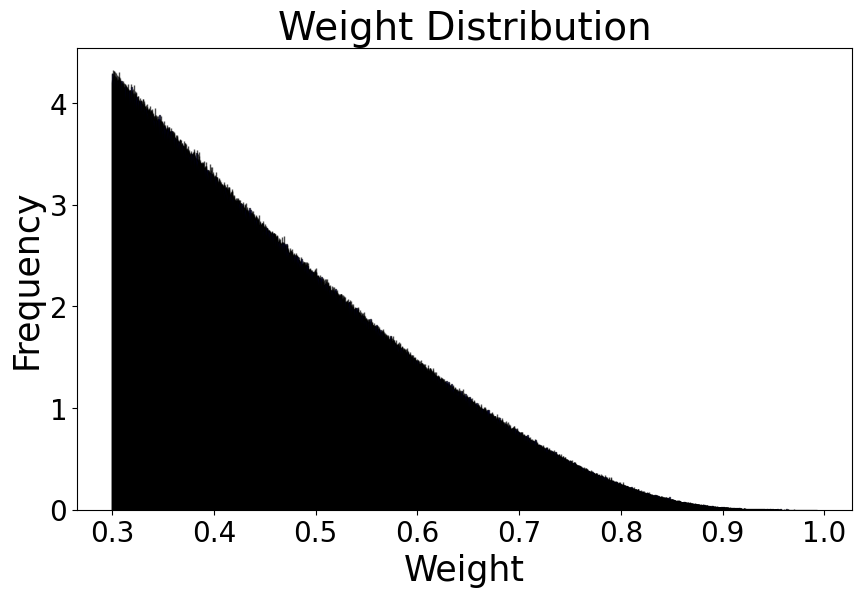

Number of clusters: 47
Number of modules: 36
IGRAPH UNW- 12939 31980014 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


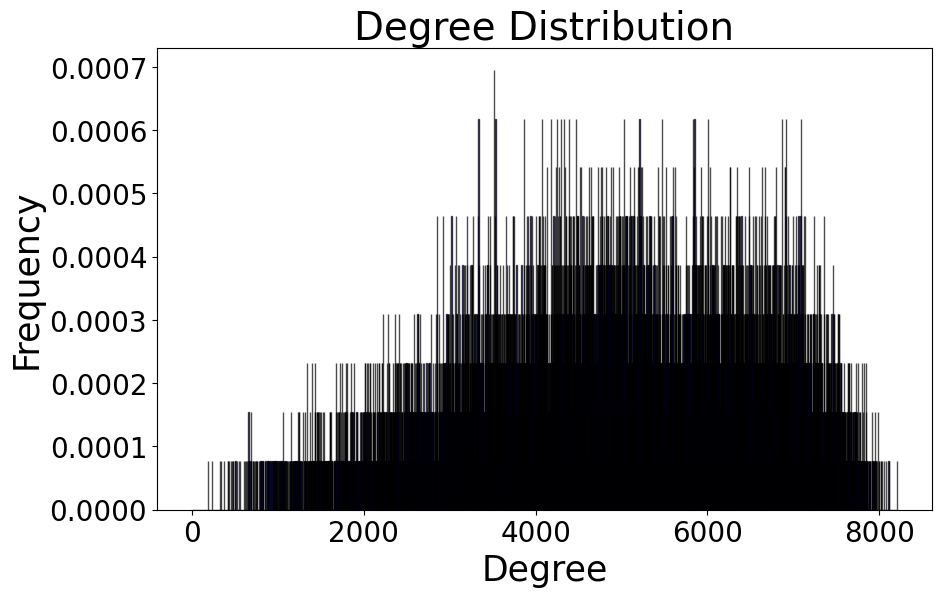

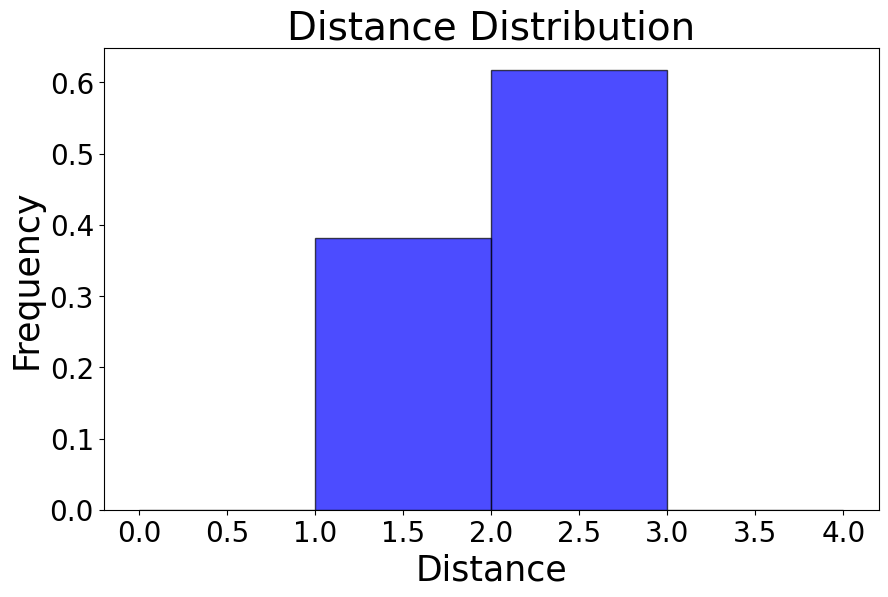

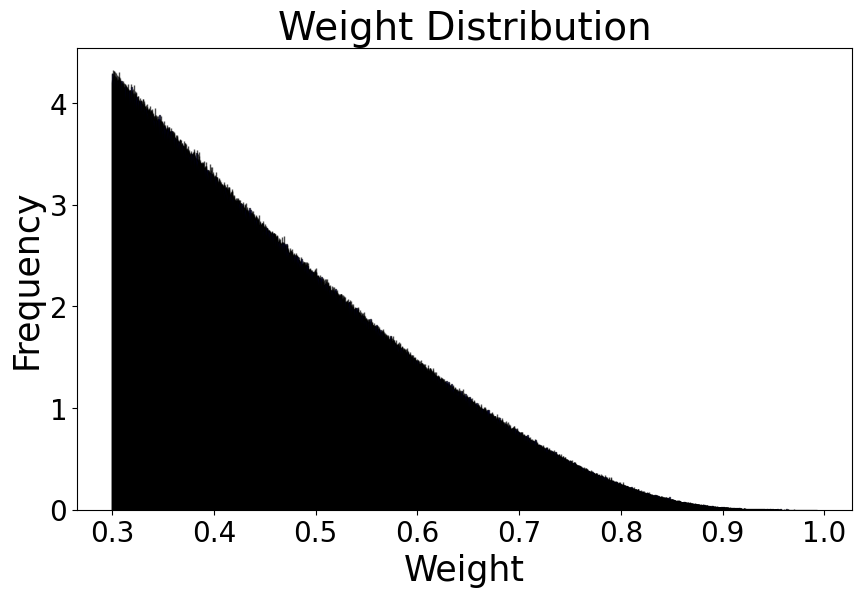

Number of clusters: 63
Number of modules: 46
IGRAPH UNW- 12939 31980014 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


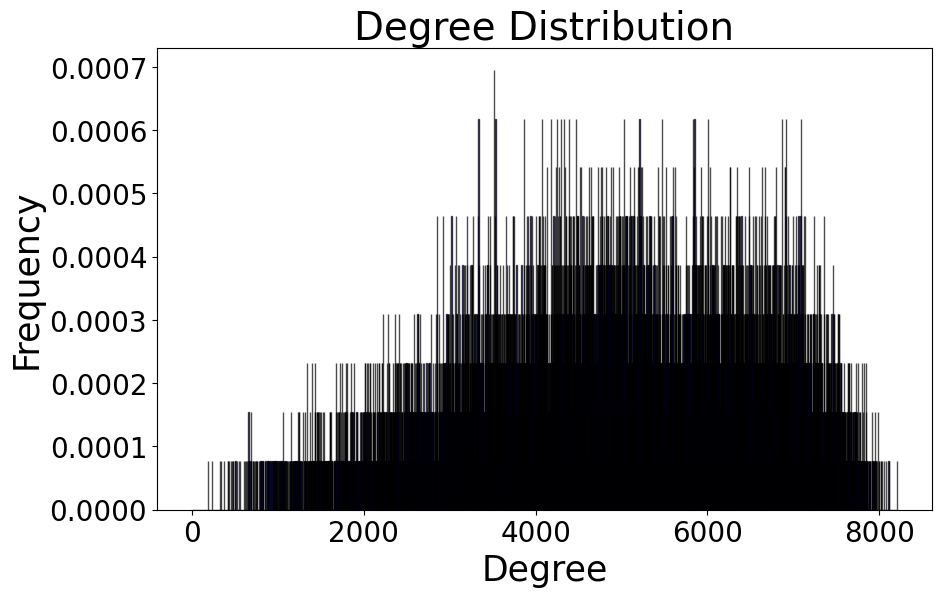

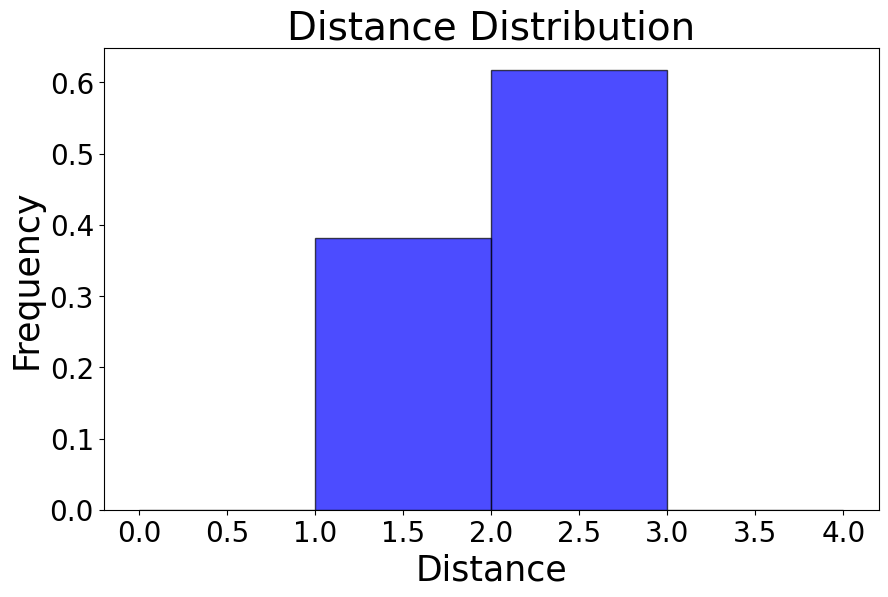

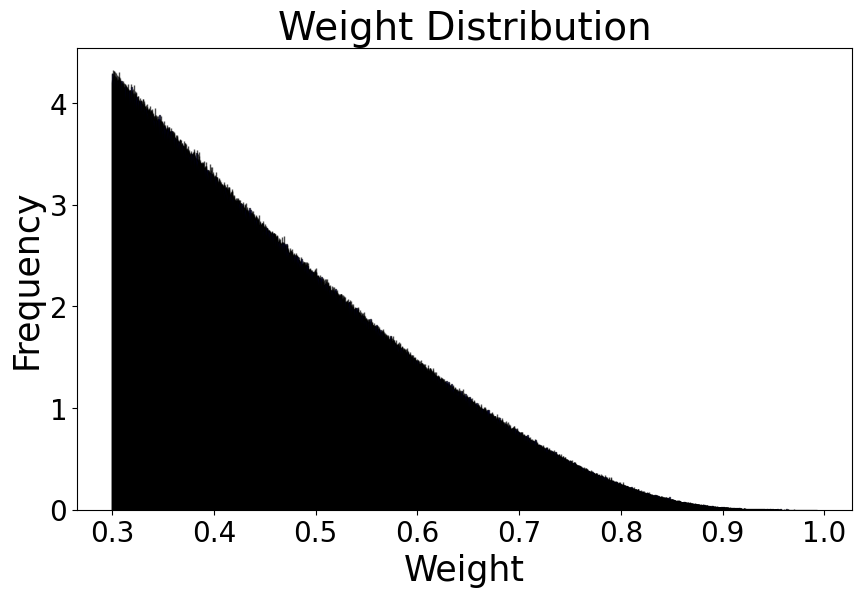

Number of clusters: 85
Number of modules: 65
IGRAPH UNW- 12939 31980014 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


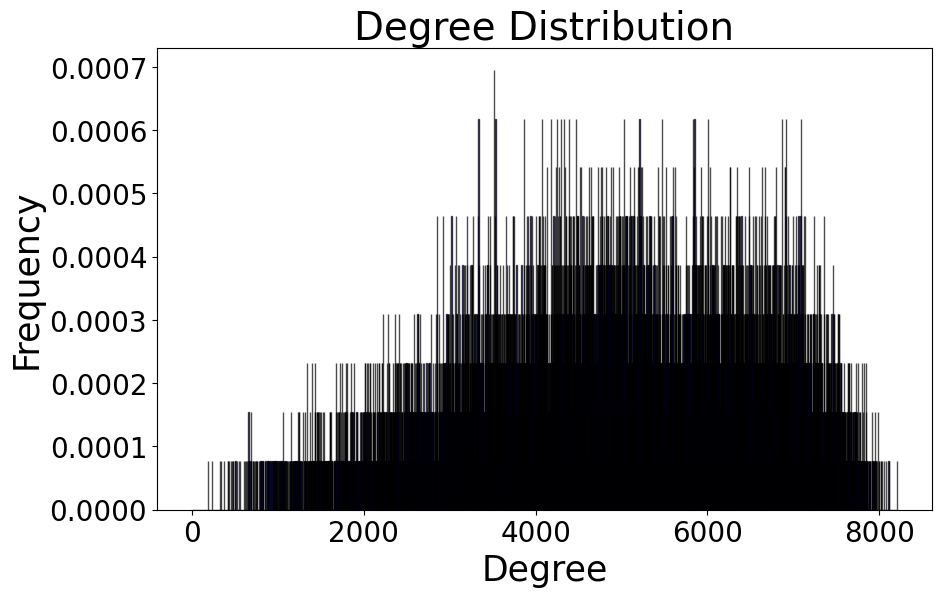

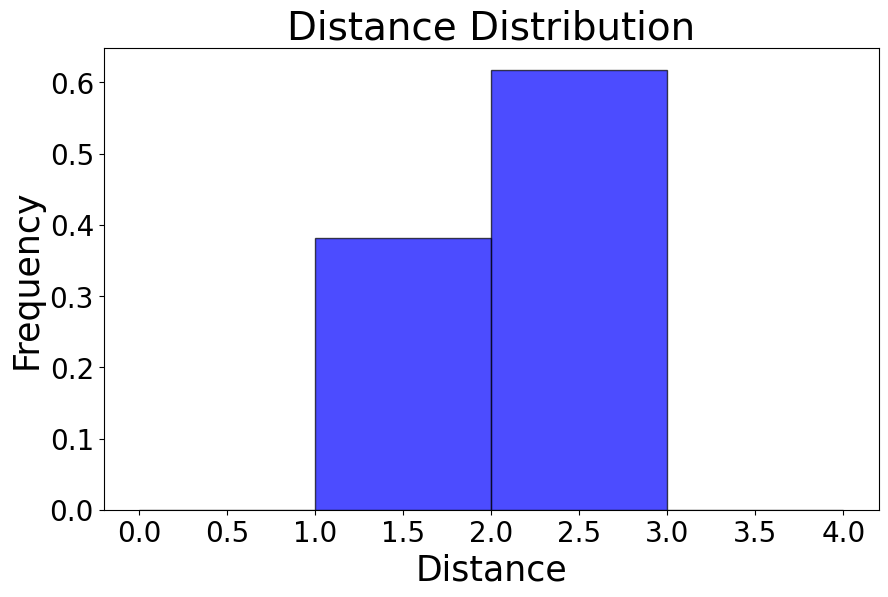

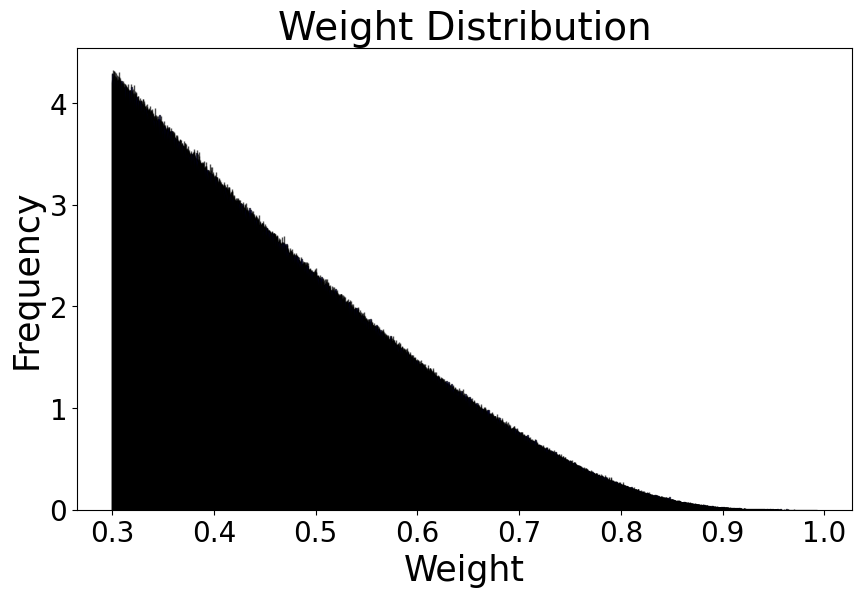

Number of clusters: 115
Number of modules: 94
IGRAPH UNW- 12939 31980014 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


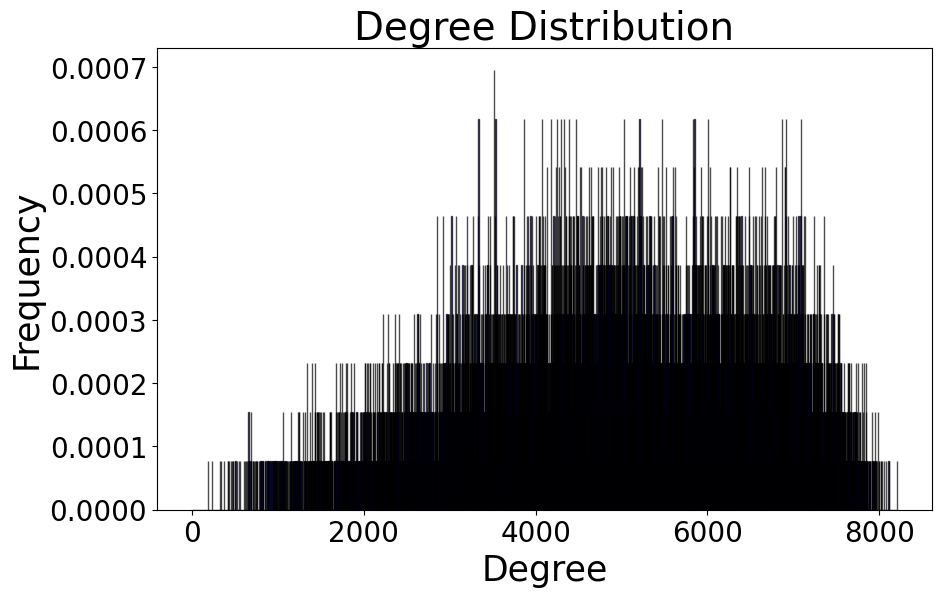

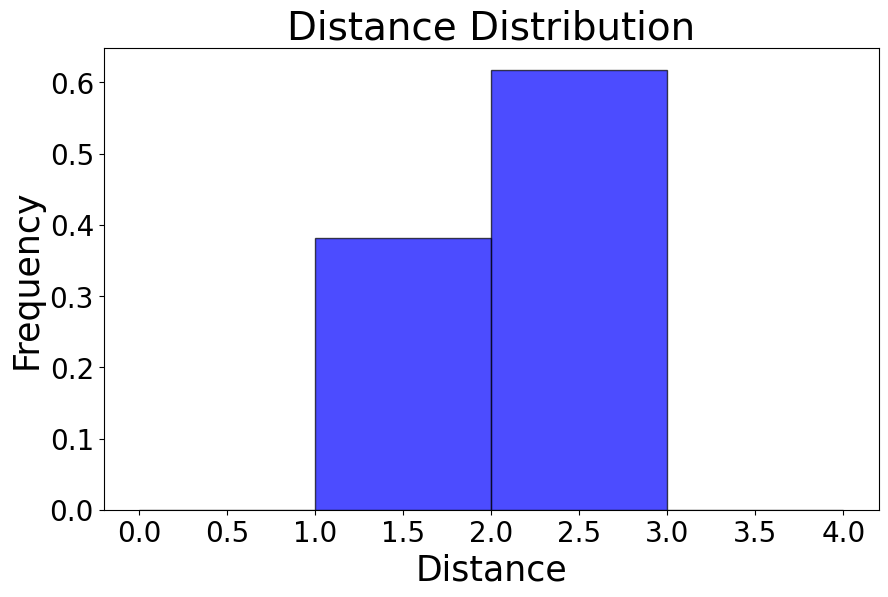

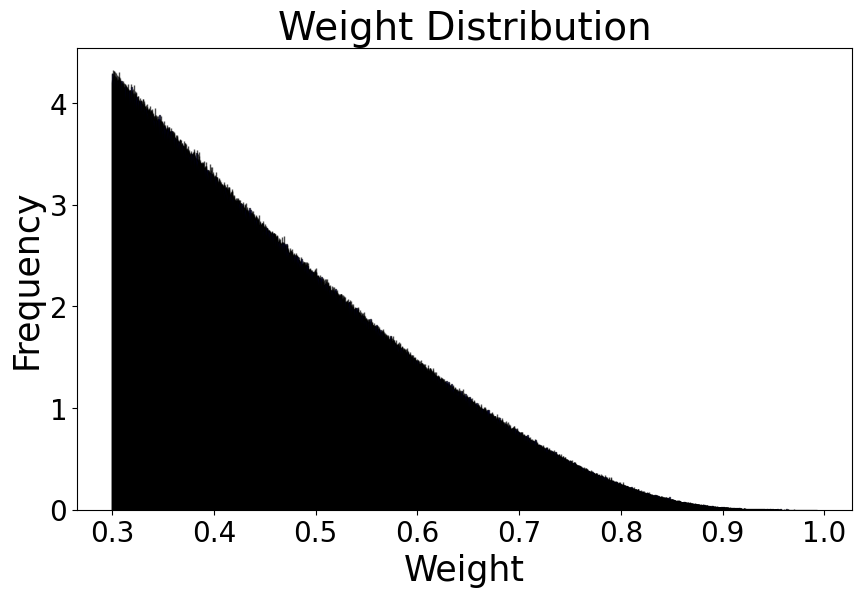

Number of clusters: 160
Number of modules: 125
IGRAPH UNW- 12939 31980014 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


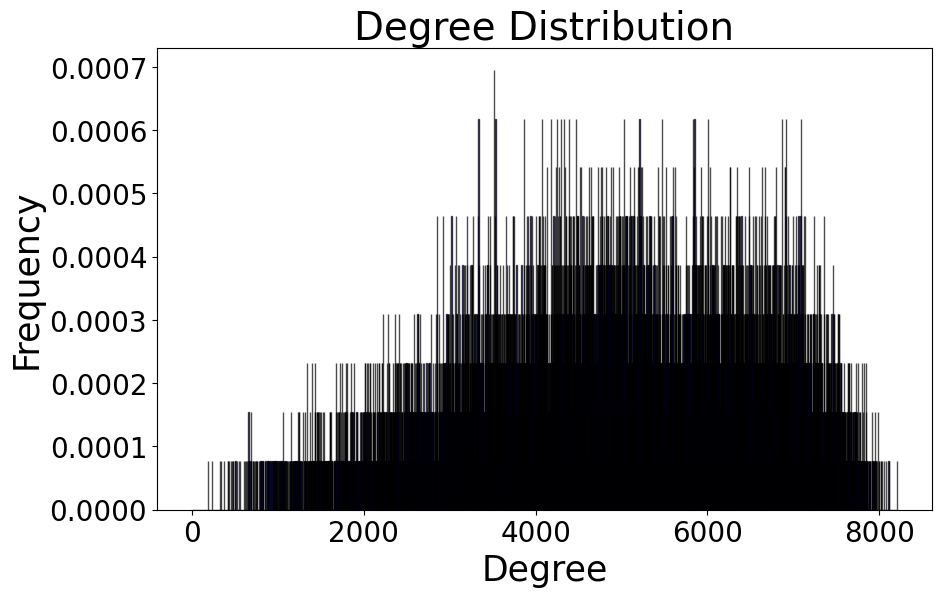

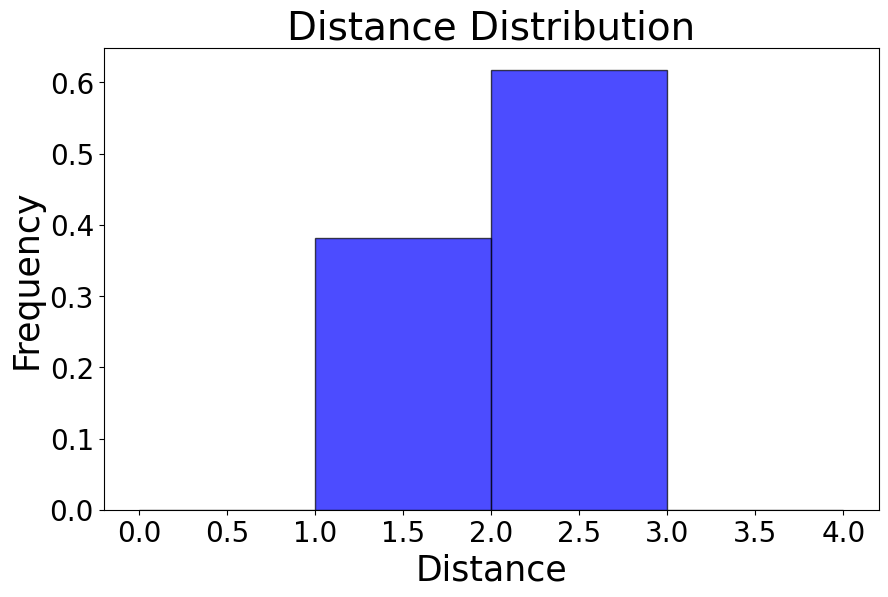

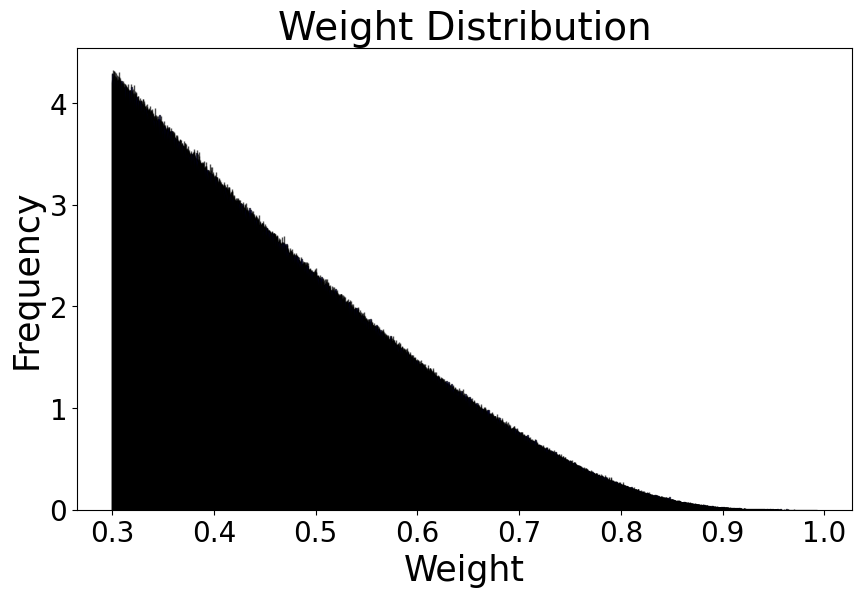

Number of clusters: 232
Number of modules: 163
IGRAPH UNW- 12939 31980014 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


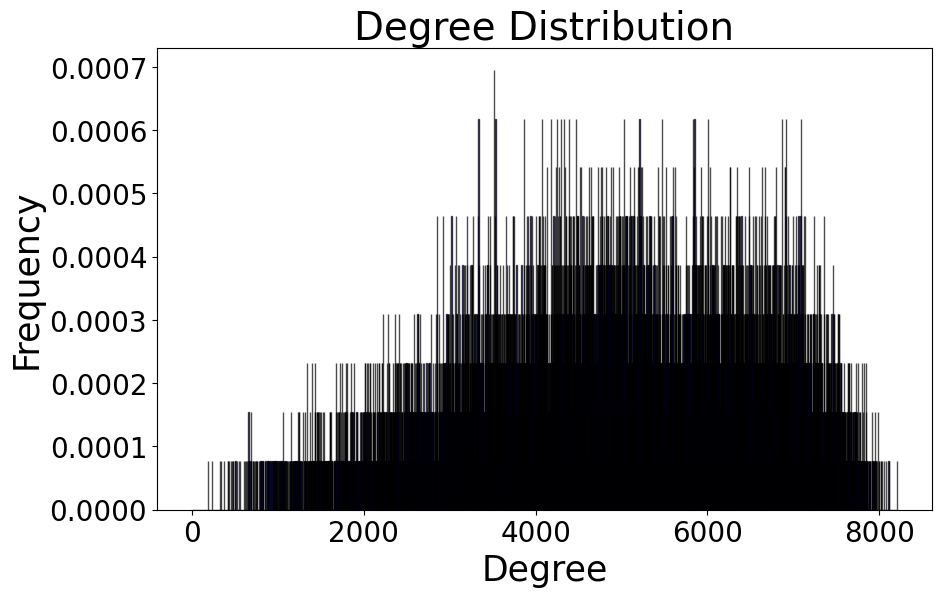

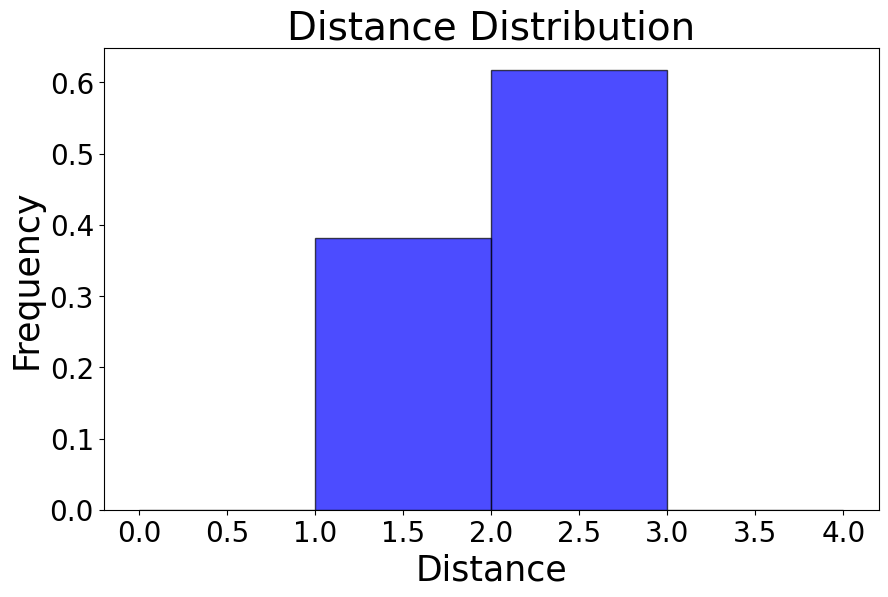

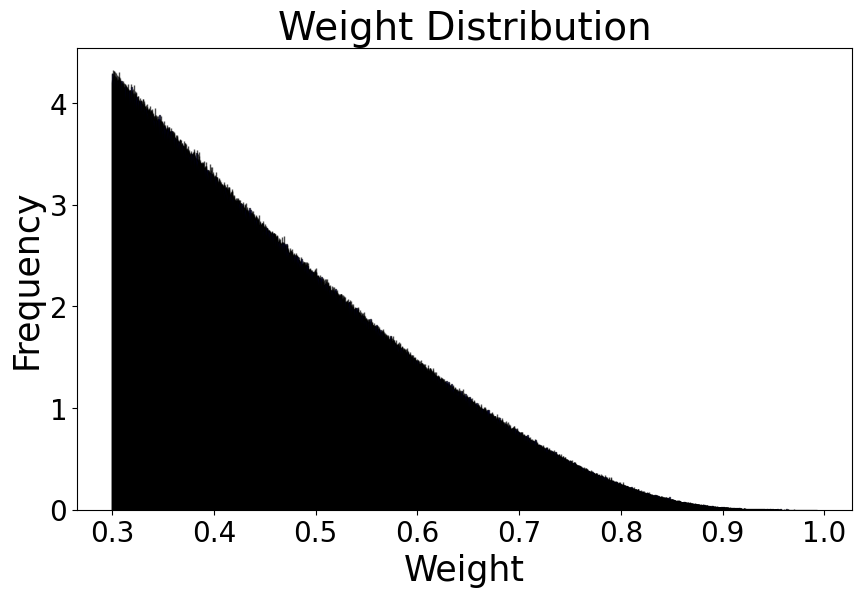

Number of clusters: 360
Number of modules: 231


In [9]:
for resolution_parameter in resolution_values:
    module_III = Leiden_pcc_to_module(pcc_matrix=pcc_III, fig_path1=f"./figures/degree_distribution_III_{resolution_parameter}.svg", fig_path2=f"./figures/distance_distribution_III_{resolution_parameter}.svg", fig_path3=f"./figures/weight_distribution_III_{resolution_parameter}.svg", pcc_threshold=0.3, resolution_parameter=resolution_parameter, seed=123456)
    module_to_json(module_dict=module_III, file_path=f"module_III_{resolution_parameter}.json")

IGRAPH UNW- 12939 33548344 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


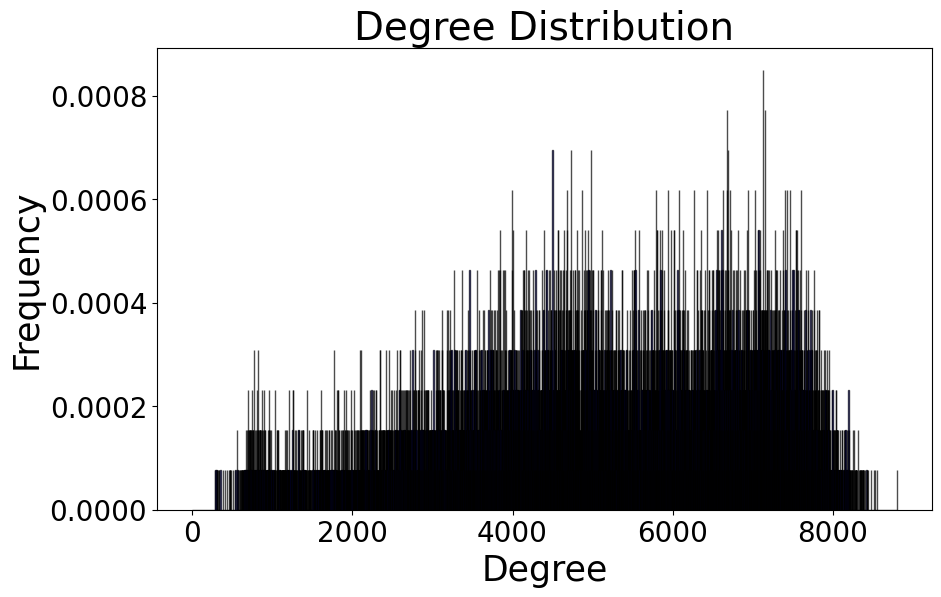

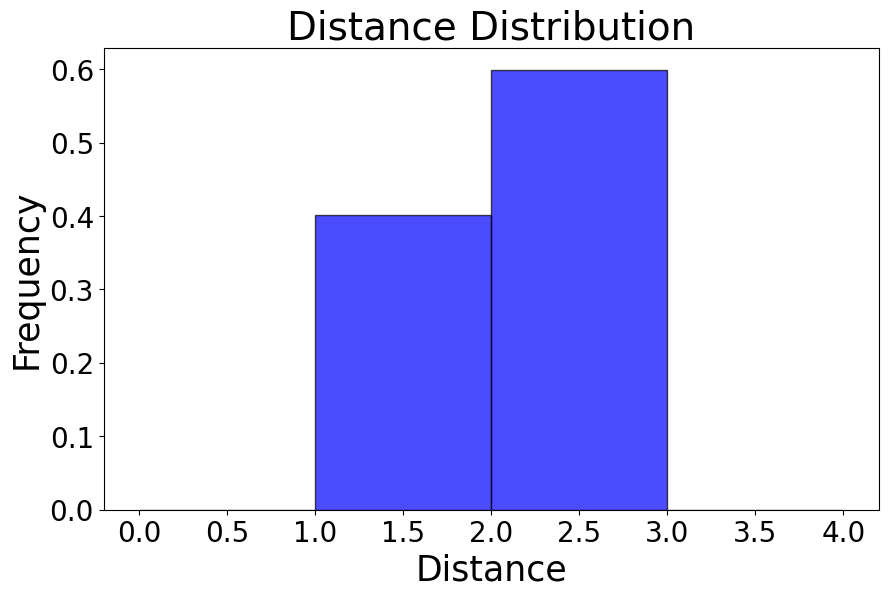

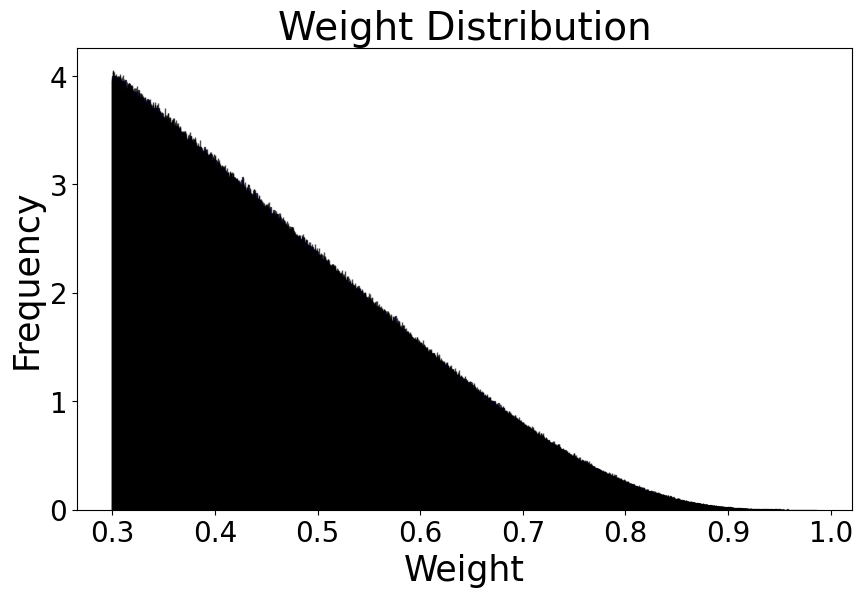

Number of clusters: 20
Number of modules: 17
IGRAPH UNW- 12939 33548344 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


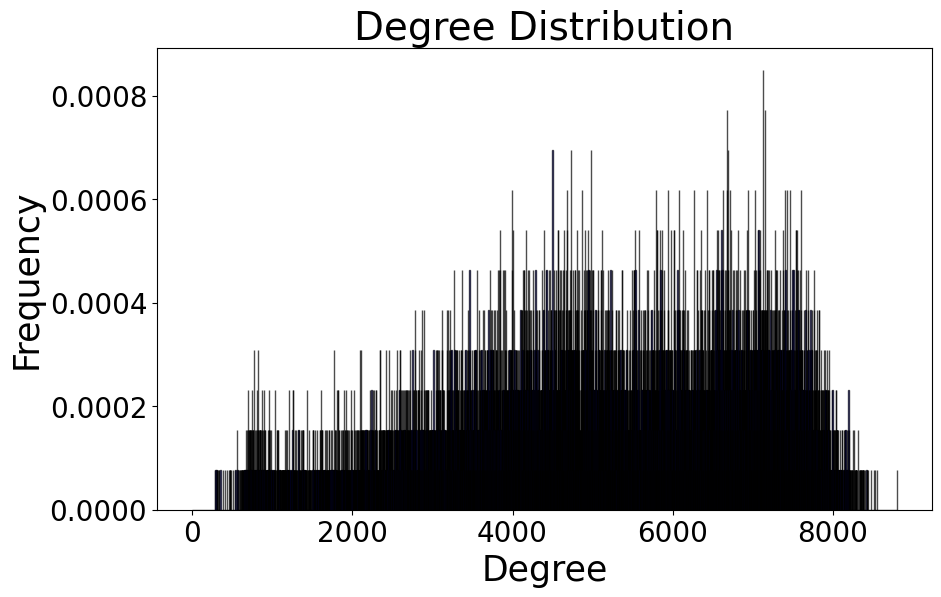

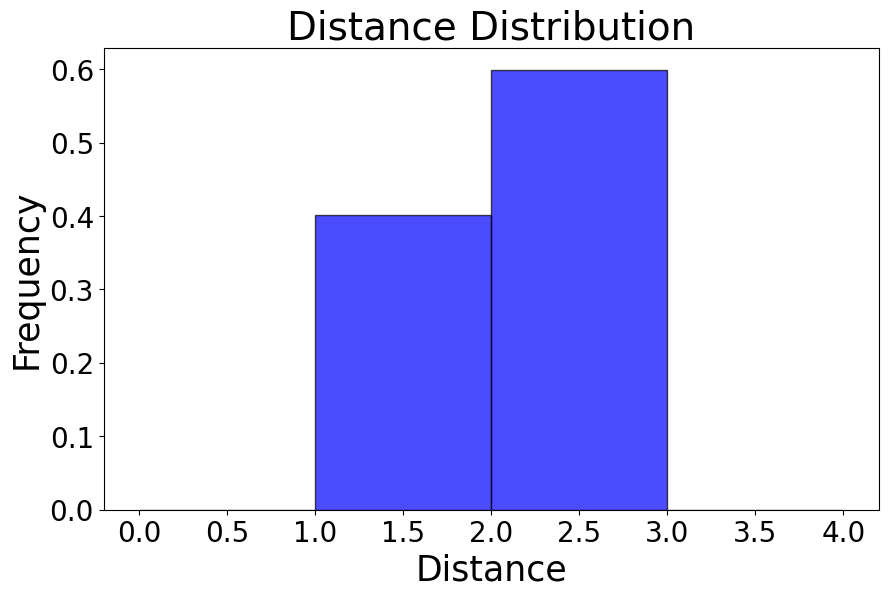

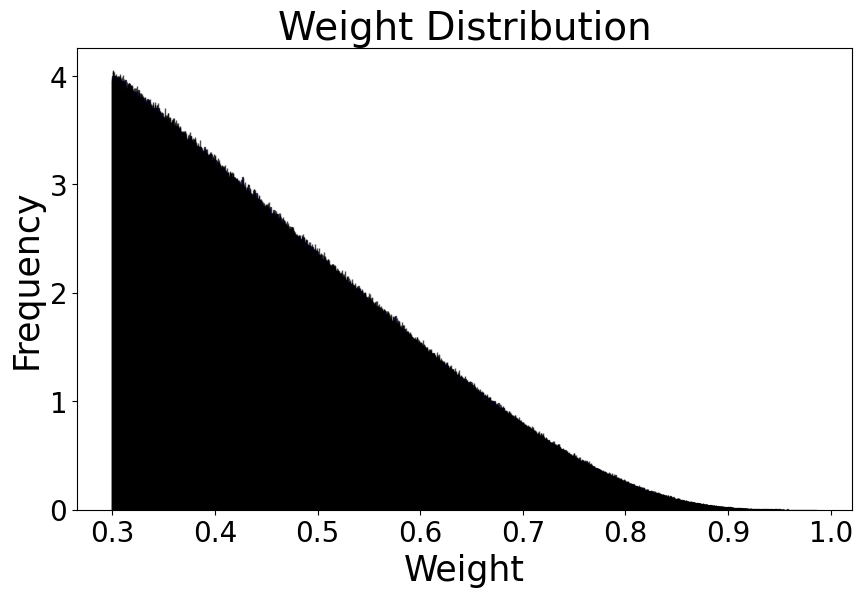

Number of clusters: 29
Number of modules: 25
IGRAPH UNW- 12939 33548344 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


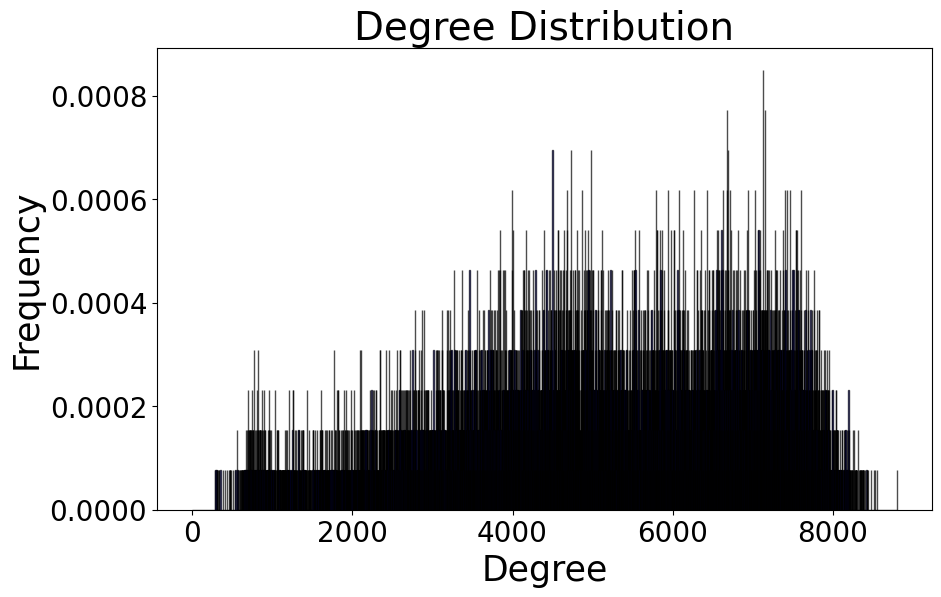

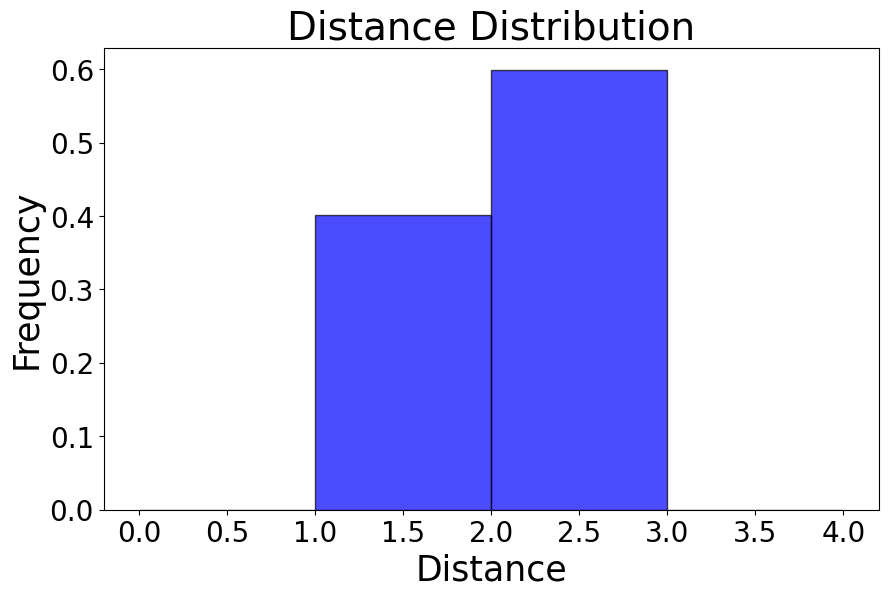

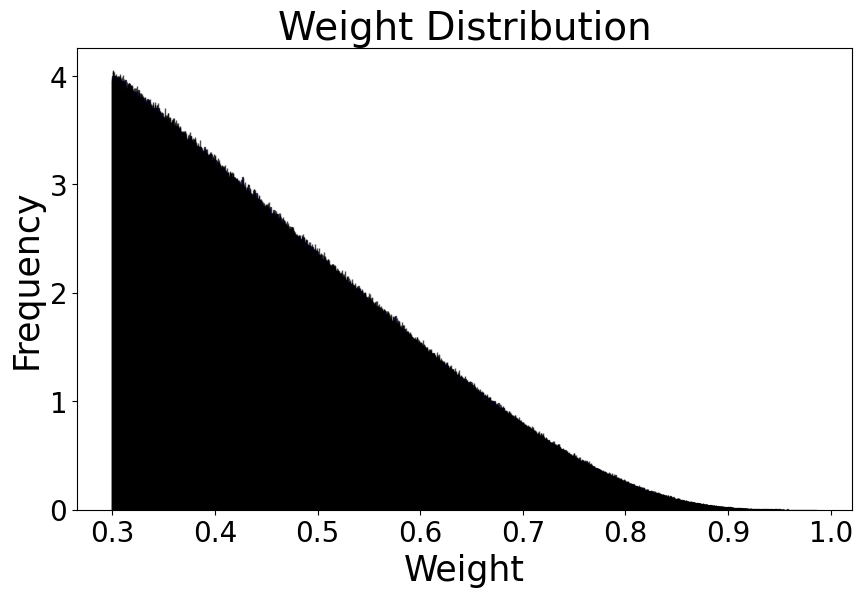

Number of clusters: 47
Number of modules: 36
IGRAPH UNW- 12939 33548344 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


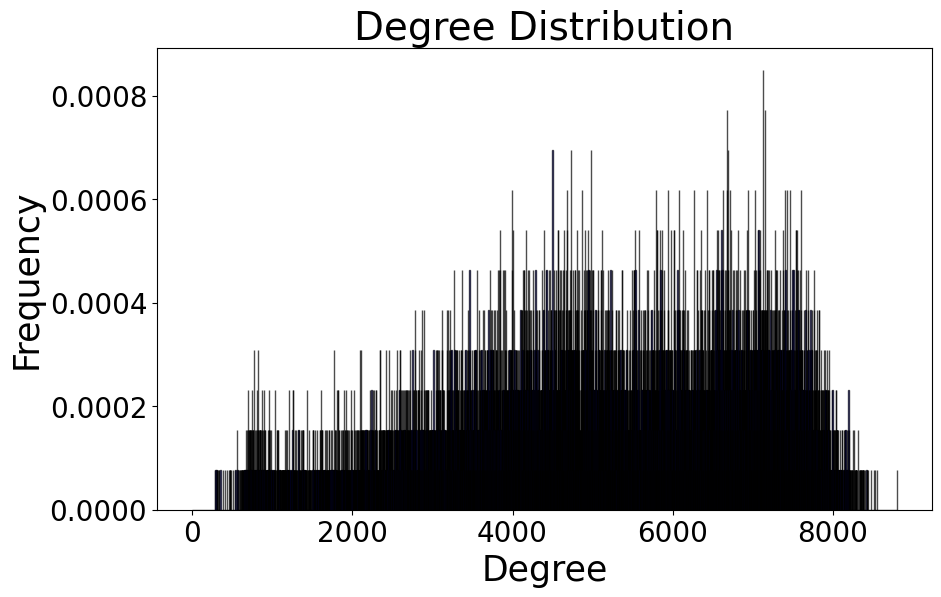

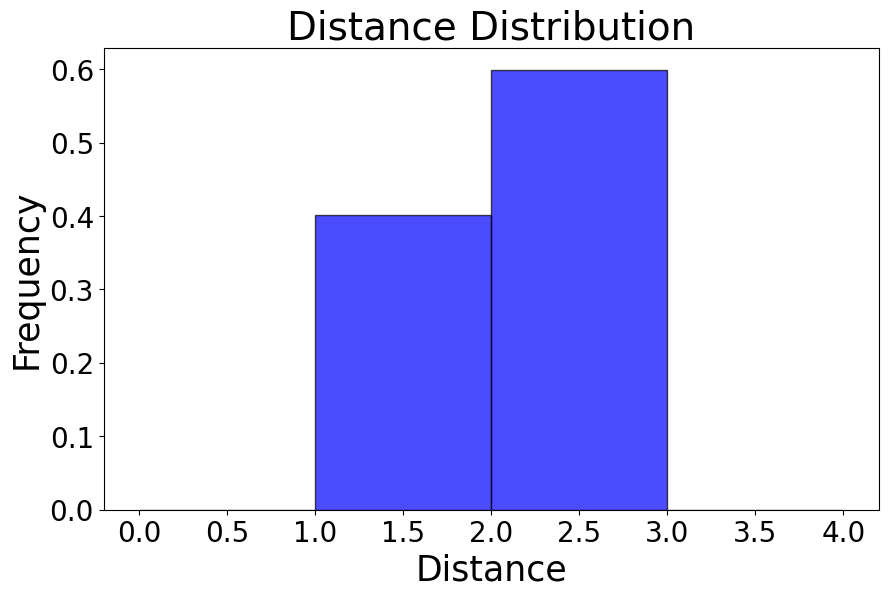

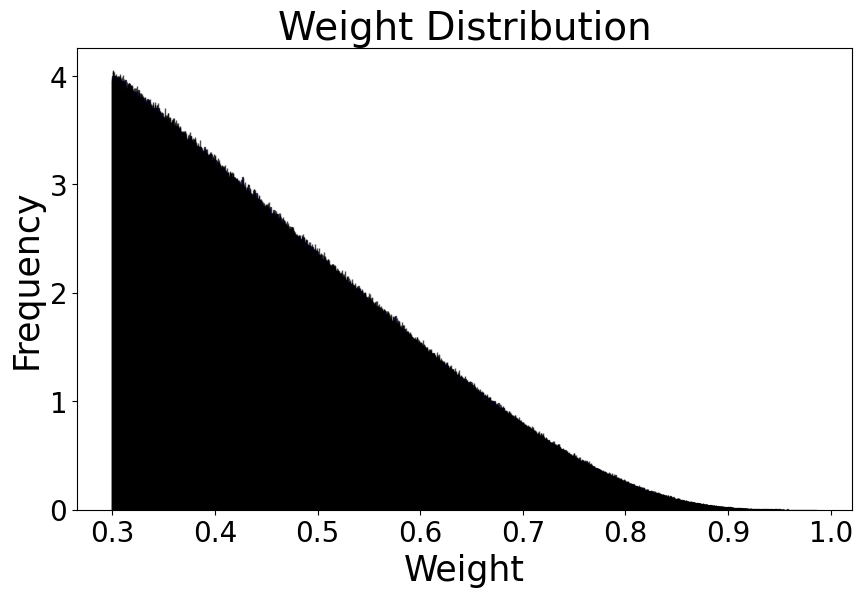

Number of clusters: 55
Number of modules: 46
IGRAPH UNW- 12939 33548344 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


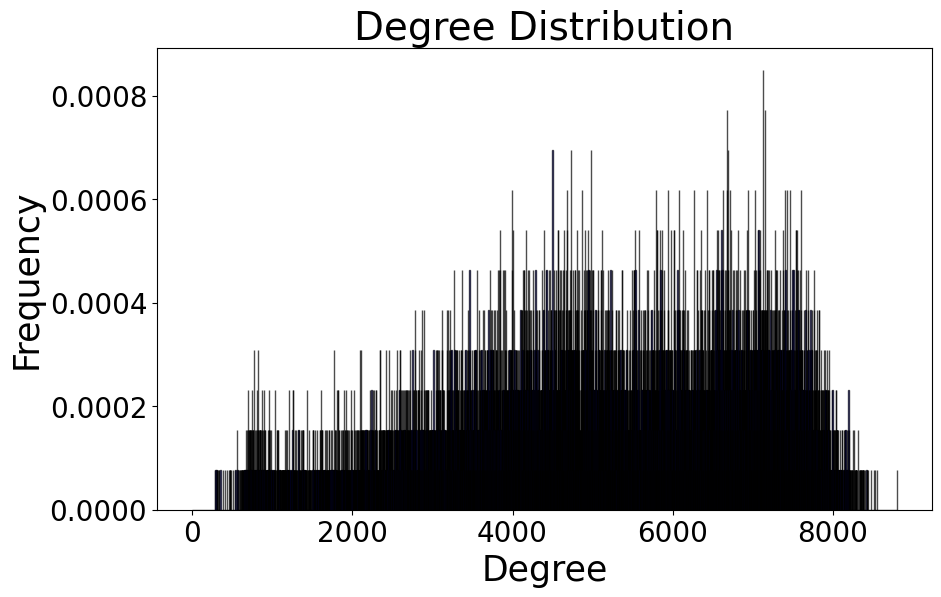

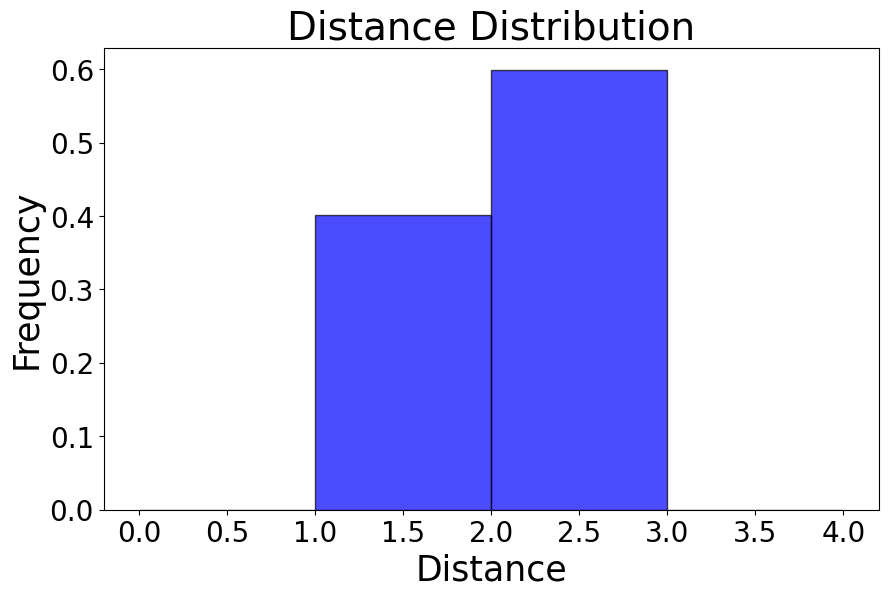

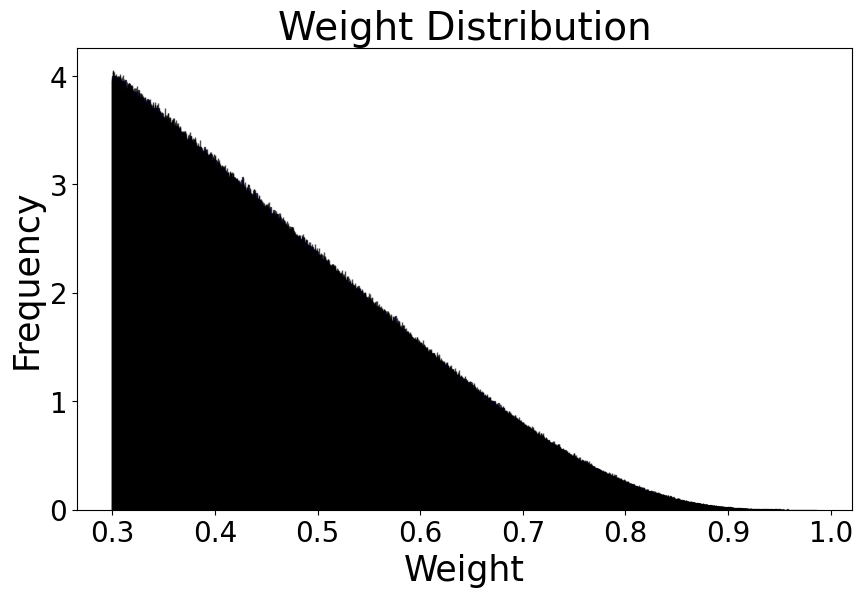

Number of clusters: 80
Number of modules: 62
IGRAPH UNW- 12939 33548344 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


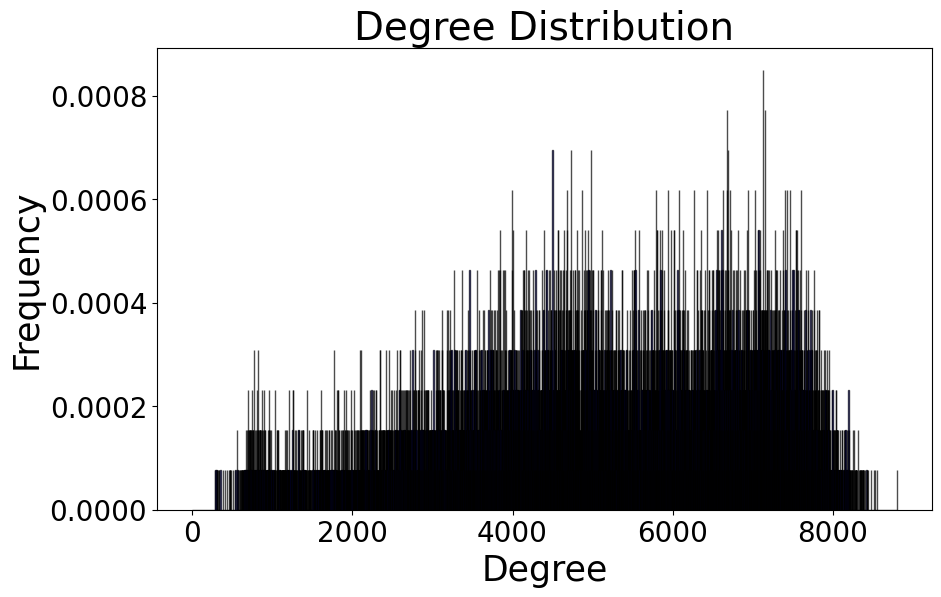

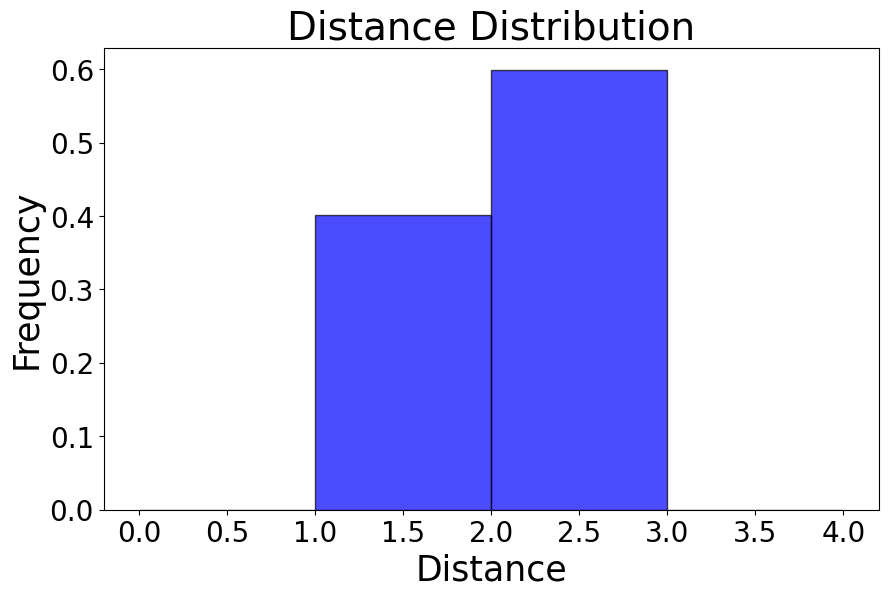

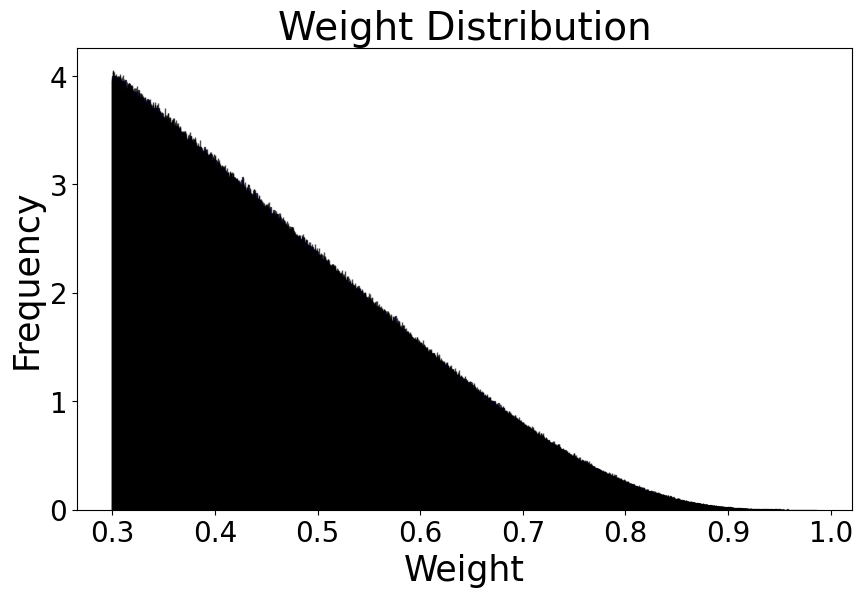

Number of clusters: 117
Number of modules: 82
IGRAPH UNW- 12939 33548344 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


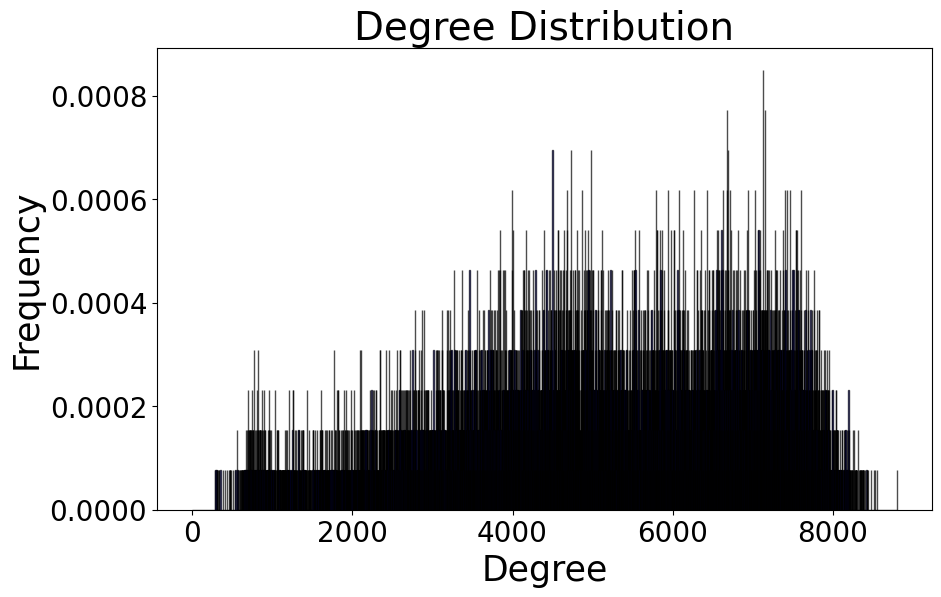

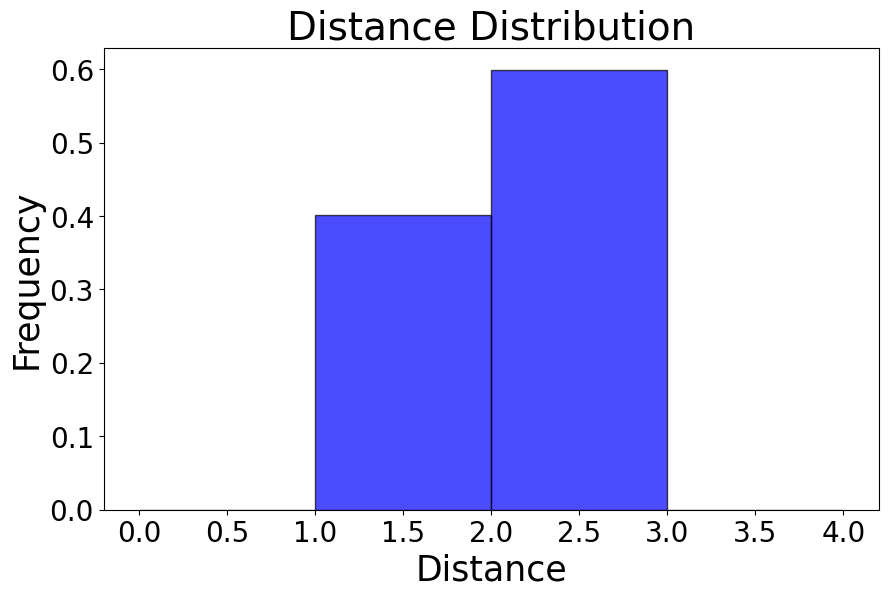

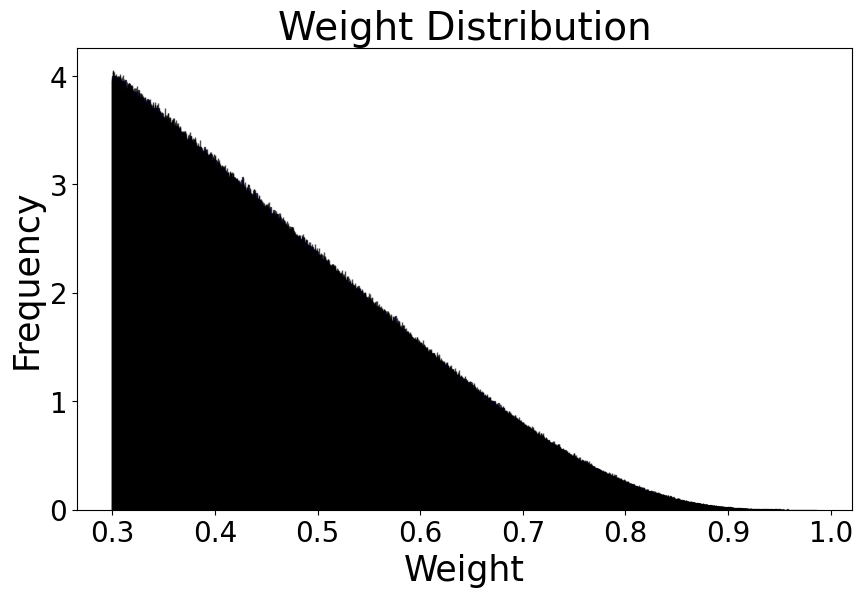

Number of clusters: 159
Number of modules: 113
IGRAPH UNW- 12939 33548344 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


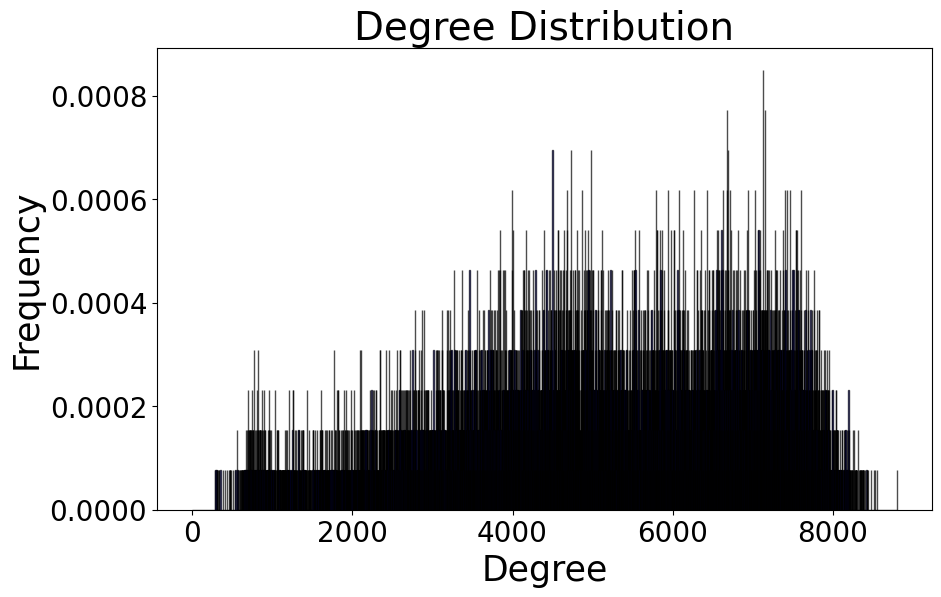

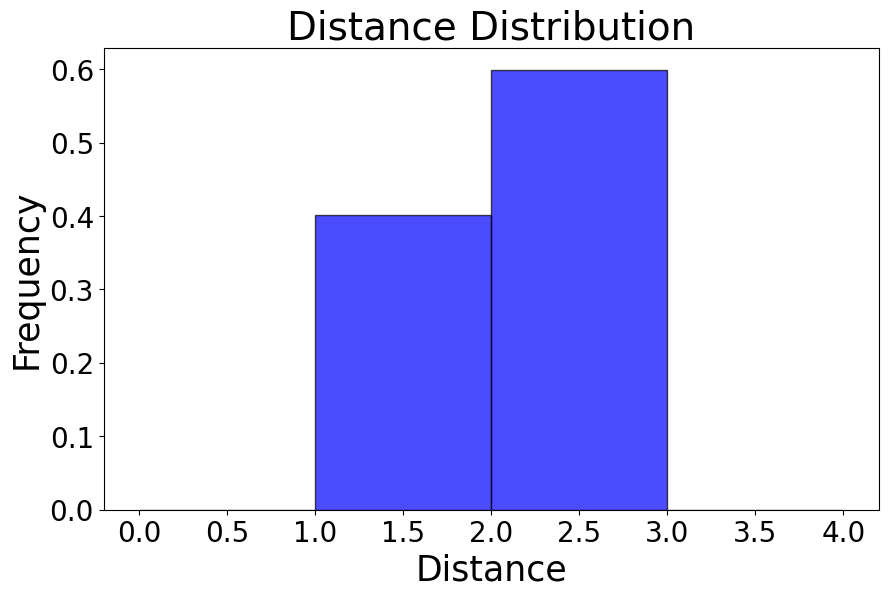

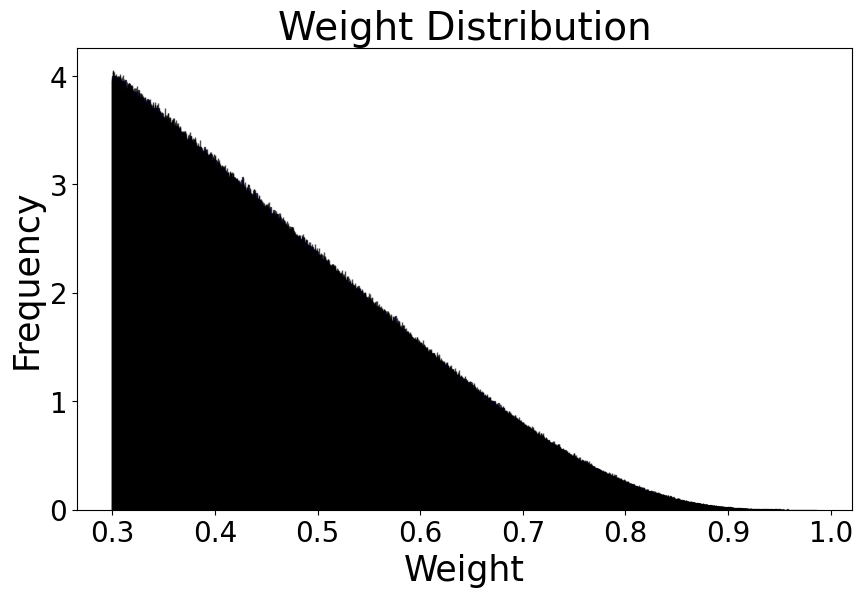

Number of clusters: 226
Number of modules: 152
IGRAPH UNW- 12939 33548344 -- 
+ attr: name (v), weight (e)
Number of connected components: 1


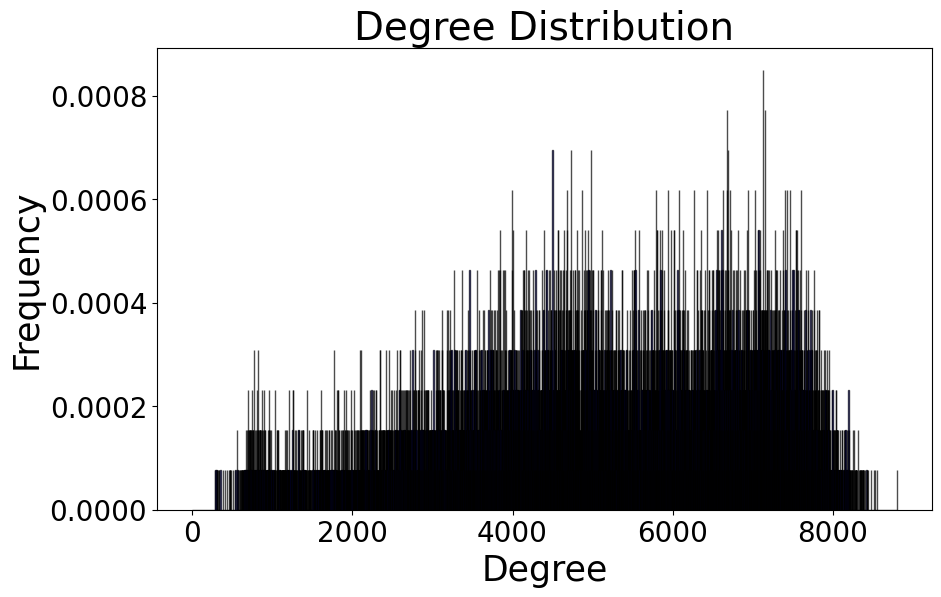

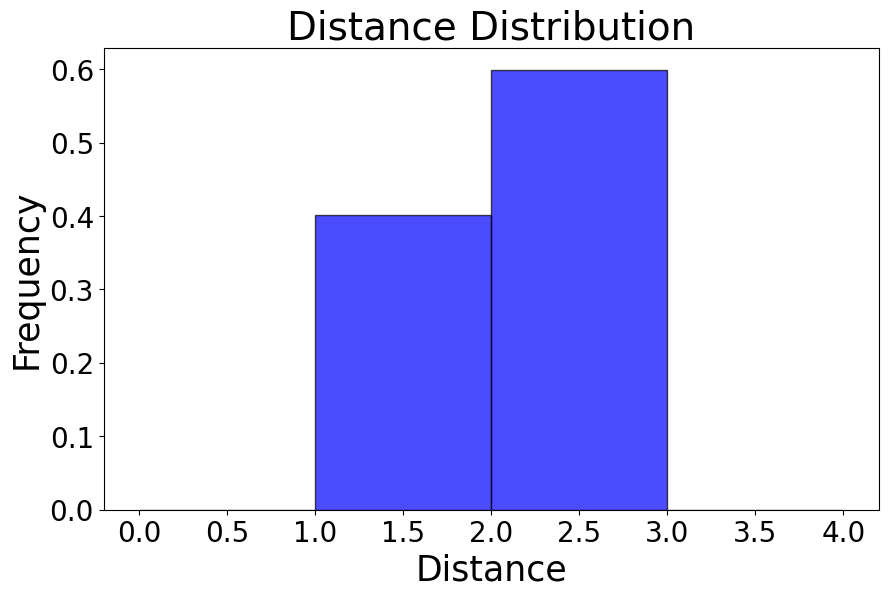

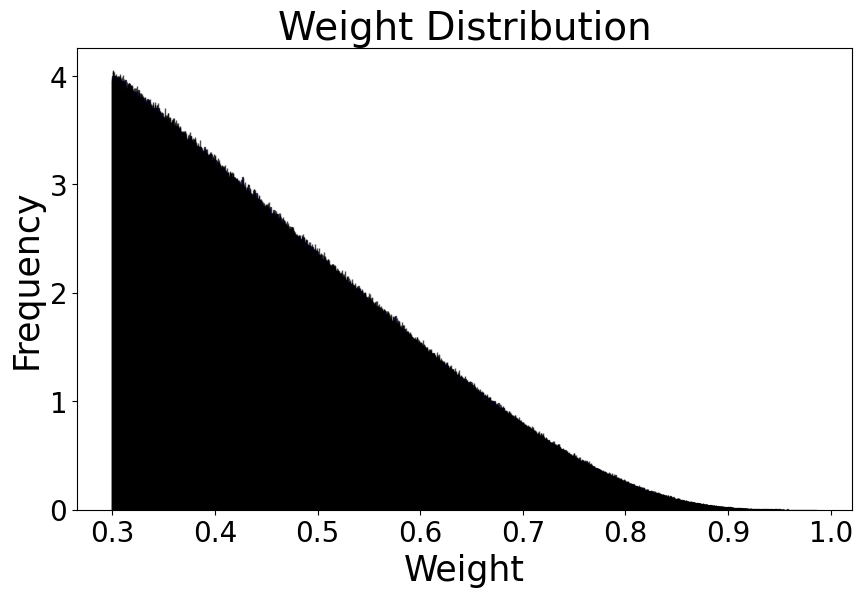

Number of clusters: 352
Number of modules: 210


In [10]:
for resolution_parameter in resolution_values:
    module_IV = Leiden_pcc_to_module(pcc_matrix=pcc_IV, fig_path1=f"./figures/degree_distribution_IV_{resolution_parameter}.svg", fig_path2=f"./figures/distance_distribution_IV_{resolution_parameter}.svg", fig_path3=f"./figures/weight_distribution_IV_{resolution_parameter}.svg", pcc_threshold=0.3, resolution_parameter=resolution_parameter, seed=123456)
    module_to_json(module_dict=module_IV, file_path=f"module_IV_{resolution_parameter}.json")